# 69: Indian matchbox label style LoRA on SD3.5-medium, with flow matching explained

Part of [Indian-Matchbox-Art-Style-Text-to-Image-Generator](https://github.com/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator).
Weights: [`sd3.5-medium/`](https://huggingface.co/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator/tree/main/sd3.5-medium) on Hugging Face.
Data: [spearb0lt/Indian-Matchbox-Labels](https://huggingface.co/datasets/spearb0lt/Indian-Matchbox-Labels).

---

## What this notebook is

The same 197 vintage Indian matchbox labels and the same trigger word `phlmx` as notebook 55, on a
different model family trained with a different objective. Notebook 55 is about the curation
workflow; this one is about the **objective**: it derives flow matching on a 2-D toy, checks it
against the diffusers source, and then trains a LoRA on Stable Diffusion 3.5-medium with it.

| | notebook 55 | this notebook |
|---|---|---|
| base model | SDXL 1.0: a U-Net, 2.57 B parameters | SD3.5-medium: an MMDiT transformer, 2.47 B parameters |
| text encoders | CLIP-L + OpenCLIP-bigG | CLIP-L + OpenCLIP-bigG + **T5-XXL** |
| training objective | predict the **noise** ε (DDPM), min-SNR-5 loss weighting | predict the **velocity** ε − x₀ along a straight path (**flow matching**), logit-normal timestep sampling, static shift 3.0 |
| LoRA targets | U-Net attention `to_q`, `to_k`, `to_v`, `to_out.0` | both streams of joint attention: `to_q/k/v/out.0` (image) and `add_q/k/v_proj`, `to_add_out` (text) |
| captions | Florence-2 auto-captions (won the caption ablation) | the hand-written `.txt` captions |
| sampler for the images | `EulerDiscreteScheduler`, 30 steps, CFG 6.0 | `FlowMatchEulerDiscreteScheduler`, 28 steps, CFG 5.0 |

**Why SD3.5-medium.** The Reddit "desi-max" style LoRA that inspired this project was trained on
`Qwen/Qwen-Image-2512`, a 20 B-parameter flow-matching transformer that does not fit a 16 to 24 GB
GPU. SD3.5-medium uses the same objective and the same family of architecture at a size that does.
§15 maps everything here onto Qwen-Image.

| part | § | what |
|---|---|---|
| 1 | 1 to 3 | the flow-matching loss on a **2-D toy**, the convention diffusers uses **checked against its source**, Euler sampling, and a side-by-side with ε-prediction |
| 1 | 4 | **rectified flow**: straight paths, and "reflow" to straighten them further |
| 1 | 5 | **timestep sampling** (uniform vs logit-normal) and the **shift** (why higher resolutions need more noise), and how diffusers applies `shift` and dynamic shifting |
| 2 | 6 | which DiT fits a 16 GB GPU, from Hub metadata: sizes, licences, gating |
| 2 | 7 | the training data |
| 2 | 8 to 9 | **caching**: three text encoders (one of them T5-XXL), then freeing them; latents |
| 2 | 10 | inside the transformer: patchify, adaLN, **joint attention**, and the LoRA targets |
| 2 | 11 to 13 | a LoRA on SD3.5-medium with the flow-matching loss, using diffusers' own timestep and weighting helpers |
| 2 | 14 | `save_lora_weights` with adapter metadata, reload into a **fresh** pipeline, fixed-seed outputs must match |
| 2 | 15 | guidance-distilled models (Flux-dev, Flux-schnell), and how this maps onto Qwen-Image |
| 2 | 16 to 17 | the run card, and **generation** |

### The published run (the outputs below)

| | |
|---|---|
| data | `matchbox_india`: 197 labels, none under 768 px, 189 train and 8 held out |
| hardware | Google Colab, NVIDIA L4, bf16 |
| resolution | 768 x 768 pixel area (2 304 image tokens), T5 sequence length 256 |
| LoRA | rank 16, alpha 16, 243 layers, 11.9 M trainable parameters (0.53 % of the transformer) |
| schedule | 1 418 optimizer steps x 4 images (gradient accumulation) = 30 views per image, lr 1e-4, 74 min, peak 13.8 GiB |
| held-out velocity error | lower than the base model at all five fixed σ (for example 0.2286 to 0.2224 at the second σ) |
| reload check | the saved file reproduces the in-memory model exactly (relative latent difference 0.0) |

| | QUICK (`FT_QUICK=1`, e.g. a 4 GB laptop GPU, or CPU) | full (Colab L4; a 16 GB T4 at `FT_RES=512`) |
|---|---|---|
| Part 1 toy | 300 steps per model, on CPU | 4 000 steps per model, on CPU |
| DiT | `hf-internal-testing/tiny-sd3-pipe` (random weights, the same `StableDiffusion3Pipeline` classes, a 1-layer transformer, 32 px) | `stabilityai/stable-diffusion-3.5-medium` (gated: accept the licence on the Hub and set `HF_TOKEN`) |
| images | 8 train + 2 held out | every usable image except 8 held out |
| purpose | **every code path executes**; the images are noise | the actual training |

> In QUICK the tiny pipeline has random weights, so every image is noise and every Part 2
> number is meaningless by construction. Part 1's toy numbers are real but noisy at 300 steps.
> Do not draw conclusions from QUICK output.


## 0. Environment

In [ ]:
import os
# Settings of the published run. Change them here, before the setup cell.
os.environ.setdefault("FT_DATA_NAME", "matchbox_india")
os.environ.setdefault("FT_TRIGGER", "phlmx")
os.environ.setdefault("FT_RUN_NAME", "69_matchbox_india")
os.environ.setdefault("FT_RES", "768")     # training area; 768 peaked at 13.8 GiB on an L4, 512 suits a 16 GB T4
# os.environ["FT_QUICK"] = "1"             # fast smoke run with tiny models

try:                                       # on Colab: keep out/ on Google Drive, and pass the Hugging Face token
    from google.colab import drive, userdata
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/finetune_runs/69", exist_ok=True)
    os.chdir("/content/drive/MyDrive/finetune_runs/69")
    try:                                   # SD3.5-medium is gated: accept its licence on the Hub, then add a secret
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except Exception:
        print("no HF_TOKEN secret found: add one (key icon in the left bar) after accepting the SD3.5-medium licence")
except ImportError:
    pass                                   # not on Colab: set HF_TOKEN in your environment


### Setup: libraries and data

The next cell runs everywhere. On Colab it first installs the libraries. Then it finds the
training images:

* `FT_DATA_NAME = "matchbox_india"` (set in the cell above): a local copy in `data/matchbox_india`
  is used if it exists; otherwise the Hugging Face dataset `spearb0lt/Indian-Matchbox-Labels`
  (about 130 MB) is downloaded into that folder. If no images can be found, the cell stops.
* `FT_STYLE_DIR` overrides it with any folder of images; each image's caption is read from a
  same-named `.txt` next to it.
* With neither, Part 2 falls back to streaming the CC0 Cooper Hewitt museum collection, the
  notebook's original demonstration data.

Do not import `huggingface_hub`, `transformers` or `diffusers` in a cell before this one: if this
cell upgrades a package that is already imported, it stops and asks for one session restart.


In [ ]:
import os as _os, sys as _sys, subprocess as _sp
from pathlib import Path as _P
try:
    import google.colab  # noqa: F401  (present on every Colab runtime)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from importlib.metadata import version as _ver, PackageNotFoundError as _PNF
    _PKGS = ["huggingface_hub", "transformers", "diffusers", "peft", "accelerate", "safetensors", "datasets"]

    def _versions():
        out = {}
        for _p in _PKGS:
            try:
                out[_p] = _ver(_p)
            except _PNF:
                out[_p] = None
        return out

    _loaded = [p for p in _PKGS if p in _sys.modules]          # already imported in this session
    _before = _versions()
    _sp.run([_sys.executable, "-m", "pip", "install", "-q", "-U", "diffusers>=0.40", "transformers>=5.15", "peft>=0.20",
             "accelerate", "safetensors", "sentencepiece", "datasets", "huggingface_hub"], check=True)
    # Colab ships an old torchao; recent peft refuses to run next to torchao < 0.16. Nothing here uses it.
    try:
        if tuple(int(x) for x in _ver("torchao").split(".")[:2]) < (0, 16):
            _sp.run([_sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"], check=True)
    except Exception:
        pass                                   # not installed: nothing to do
    _changed = [p for p in _loaded if _versions()[p] != _before[p]]
    if _changed:                   # the old versions are still in memory; mixing them with the new files breaks imports
        raise RuntimeError(f"upgraded {_changed} after they were imported in this session. The new versions are "
                           "installed: do Runtime -> Restart session, then Run all again (this cell then passes).")

HF_DATASET = _os.environ.get("FT_HF_DATASET", "spearb0lt/Indian-Matchbox-Labels")     # the training images
_EXTS = (".jpg", ".jpeg", ".png", ".webp")
_has_imgs = lambda d: d.is_dir() and any(q.suffix.lower() in _EXTS for q in d.rglob("*"))
if not _os.environ.get("FT_STYLE_DIR") and _os.environ.get("FT_DATA_NAME") == "matchbox_india":
    _local = _P.cwd() / "data" / "matchbox_india"
    if not _has_imgs(_local):                                   # not here yet: download it once
        from huggingface_hub import snapshot_download
        snapshot_download(HF_DATASET, repo_type="dataset", local_dir=str(_local))
    _dir = _local / "images" if _has_imgs(_local / "images") else _local
    if not _has_imgs(_dir):
        raise RuntimeError(f"no images found in {_local} (dataset {HF_DATASET}); set FT_STYLE_DIR to a folder of images")
    _os.environ["FT_STYLE_DIR"] = str(_dir)
print(f"{'Colab' if IN_COLAB else 'local'} | FT_STYLE_DIR = {_os.environ.get('FT_STYLE_DIR')}")


In [5]:
import sys

# Windows consoles default to cp1252 and cannot print some characters used below.
# Jupyter is unaffected; this matters when the notebook runs as a script.
if sys.platform == "win32":
    for _s in (sys.stdout, sys.stderr):
        try:
            _s.reconfigure(encoding="utf-8")
        except Exception:
            pass

In [6]:
import os, gc, json, math, time, random, re, warnings, subprocess, inspect
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

DEV = "cuda" if torch.cuda.is_available() else "cpu"
# including_emulation=False: the default returns True on a T4 and silently selects slow emulated bf16
BF16 = torch.cuda.is_bf16_supported(including_emulation=False) if DEV == "cuda" else False
DTYPE = torch.bfloat16 if BF16 else torch.float16      # T4/P100 -> fp16 + GradScaler
if DEV == "cpu":
    DTYPE = torch.float32
AMP = DEV == "cuda"
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 2**30 if DEV == "cuda" else 0.0
torch.set_float32_matmul_precision("high")

QUICK = os.environ.get("FT_QUICK", "0") == "1"
if QUICK:
    print("=" * 78)
    print("QUICK MODE (FT_QUICK=1): short toy runs, tiny random-weight SD3 pipe at 32 px.")
    print("Every code path runs. Part 2 images are noise. Draw NO conclusion from any number.")
    print("=" * 78)

print(f"device {DEV} | bf16 {BF16} -> {DTYPE}")
if DEV == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"gpu {torch.cuda.get_device_name(0)}  VRAM {free/2**30:.2f} GiB free / {total/2**30:.2f} GiB")


def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


def free_mem():
    gc.collect()
    if DEV == "cuda":
        torch.cuda.empty_cache()


SEED = 42
set_seed(SEED)

# ---- Part 1 knobs (toy, always on CPU: cheap and bit-reproducible) ----
TOY_STEPS = 300 if QUICK else 4000
TOY_BATCH = 512 if QUICK else 1024
N_EVAL = 1000 if QUICK else 4000
N_PAIRS = 2000 if QUICK else 20000
STEP_GRID = [1, 2, 4, 8, 16, 64]

# ---- Part 2 knobs ----
PIPE_ID = "hf-internal-testing/tiny-sd3-pipe" if QUICK else "stabilityai/stable-diffusion-3.5-medium"
# Same pipeline class, fp16 variant published, but a non-commercial research licence (§6):
# PIPE_ID = "stabilityai/stable-diffusion-3-medium-diffusers"
DATA_ID = "biglam/cooper-hewitt-alt-text"      # CC0 museum images + human-written descriptions (notebook 55 §2.1)
CLIP_ID = "openai/clip-vit-base-patch32"
TRIGGER = os.environ.get("FT_TRIGGER", "chmx")
RES = 32 if QUICK else int(os.environ.get("FT_RES", "512"))   # training area RES x RES; 768/1024 need more VRAM (L4/A100)
assert QUICK or RES % 64 == 0, "FT_RES must be a multiple of 64"
N_TRAIN = 8 if QUICK else 40
N_HOLD = 2 if QUICK else 8
MAX_SEQ = 32 if QUICK else 256                 # T5 tokens; 256 is encode_prompt's default
RANK = 4 if QUICK else 16
LORA_ALPHA = RANK                              # alpha == r: scale 1.0
LR = 1e-4
BATCH = 2 if QUICK else 1
GRAD_ACC = 1 if QUICK else 4
MAX_STEPS = 6 if QUICK else 600                # a floor; with your own folder §7 raises it to reach TARGET_VIEWS
EVAL_EVERY = 3 if QUICK else 150              # with your own folder §7 sets ~8 evaluations per run
TARGET_VIEWS = 30                              # times each training image is seen (own folder), as in notebook 55 §6
GEN_STEPS = 4 if QUICK else 28
GUIDANCE = 5.0                                 # > 1 so the CFG path runs in QUICK too
GEN_BS = 2
WEIGHTING = "logit_normal"                     # timestep density (§5, §12)
LOSS_WEIGHTING = "none"                        # per-sigma loss weight (§12)
OUT = Path("out") / (os.environ.get("FT_RUN_NAME") or ("69_flow_dit_lora_quick" if QUICK else "69_flow_dit_lora"))
OUT.mkdir(parents=True, exist_ok=True)
MEAS = {}                                      # every measured number goes into CARD.json

device cuda | bf16 True -> torch.bfloat16
gpu NVIDIA L4  VRAM 21.84 GiB free / 22.03 GiB


---

# Part 1: The objective, from first principles, on a 2-D toy

## 1. A toy distribution and one network for both objectives

Eight Gaussian blobs on a ring. It is small enough to train in seconds on a CPU, and it has a
property real images share: the data sits on a few separated modes with empty space between
them. Poor samplers put points in that space, and a scatter plot shows it at a glance.

The same small MLP is trained twice. It takes $(x, \text{time})$ and outputs a 2-vector. Once
the output is read as a **velocity**, once as **noise**. Only the target and the sampler differ.

In [7]:
from diffusers import FlowMatchEulerDiscreteScheduler, DDPMScheduler, DDIMScheduler
from diffusers.training_utils import compute_density_for_timestep_sampling, compute_loss_weighting_for_sd3

K_MODES, RADIUS, MODE_STD = 8, 2.0, 0.12
CENTERS = RADIUS * torch.stack([torch.tensor([math.cos(2 * math.pi * k / K_MODES),
                                              math.sin(2 * math.pi * k / K_MODES)]) for k in range(K_MODES)])


def sample_data(n, g):
    idx = torch.randint(0, K_MODES, (n,), generator=g)
    return CENTERS[idx] + MODE_STD * torch.randn(n, 2, generator=g)


class TimeMLP(nn.Module):
    """(x, s) -> 2-vector.  s in [0, 1] is sigma (flow) or t/T (DDPM)."""

    def __init__(self, hidden=128, n_freq=8):
        super().__init__()
        self.register_buffer("freqs", torch.exp(torch.linspace(0.0, math.log(100.0), n_freq)))
        self.net = nn.Sequential(nn.Linear(2 + 2 * n_freq, hidden), nn.SiLU(),
                                 nn.Linear(hidden, hidden), nn.SiLU(),
                                 nn.Linear(hidden, hidden), nn.SiLU(),
                                 nn.Linear(hidden, 2))

    def forward(self, x, s):
        a = s[:, None] * self.freqs[None]
        return self.net(torch.cat([x, torch.sin(a), torch.cos(a)], dim=-1))


def swd(a, b, n_proj=128, seed=0):
    """Sliced Wasserstein-1: mean |sorted projection difference| over random directions. 0 = same distribution."""
    g = torch.Generator().manual_seed(seed)
    P = F.normalize(torch.randn(2, n_proj, generator=g), dim=0)
    return float(((a @ P).sort(0).values - (b @ P).sort(0).values).abs().mean())


def off_mode(x, k=4.0):
    """Fraction of points farther than k std from every mode centre: points 'between the blobs'."""
    return float((torch.cdist(x, CENTERS).min(1).values > k * MODE_STD).float().mean())


REF = sample_data(N_EVAL, torch.Generator().manual_seed(999))
print(f"toy: {K_MODES} modes on a radius-{RADIUS} ring, std {MODE_STD}; eval sets of {N_EVAL} points")
print(f"sanity floor: SWD between two fresh data samples = "
      f"{swd(REF, sample_data(N_EVAL, torch.Generator().manual_seed(7))):.4f}, off-mode {off_mode(REF):.3f}")

toy: 8 modes on a radius-2.0 ring, std 0.12; eval sets of 4000 points
sanity floor: SWD between two fresh data samples = 0.0473, off-mode 0.000


## 2. Flow matching: the convention diffusers uses, checked against its source

Write $x_0$ for data and $\varepsilon \sim \mathcal N(0, I)$ for noise. The **straight
(rectified-flow) path** between them is

$$x_\sigma = (1-\sigma)\,x_0 + \sigma\,\varepsilon,\qquad \sigma\in[0,1],$$

and along it the velocity is constant: $\dfrac{dx_\sigma}{d\sigma} = \varepsilon - x_0$. The
**conditional flow-matching loss** regresses a network onto that velocity:

$$\mathcal L_{\text{CFM}} = \mathbb E_{x_0,\varepsilon,\sigma}\big\lVert v_\theta(x_\sigma,\sigma,c) - (\varepsilon - x_0)\big\rVert^2 .$$

Sampling integrates $dx/d\sigma = v_\theta$ from $\sigma=1$ (noise) to $\sigma=0$ (data). Euler's
method gives $x \leftarrow x + (\sigma_{\text{next}} - \sigma)\,v_\theta$ with
$\sigma_{\text{next}} < \sigma$.

**Conventions differ between papers.** Some write $t=0$ for noise and $t=1$ for data, and the
velocity then has the opposite sign. So we read diffusers 0.40.0's
`FlowMatchEulerDiscreteScheduler` instead of assuming:

* `scale_noise` returns `sigma * noise + (1.0 - sigma) * sample`. So **σ = 1 is pure noise** and
  the "sample" is data. That is the path above.
* `step` (non-stochastic) returns `sample + dt * model_output` with `dt = sigma_next - sigma`,
  which is negative. So the model output must be $+(\varepsilon - x_0)$.
* `timesteps = sigmas * num_train_timesteps`. The pipelines pass `t` (0-1000) to the
  transformer, not σ.

The two assertions below turn that reading into checks.

In [8]:
fm = FlowMatchEulerDiscreteScheduler(num_train_timesteps=1000, shift=1.0)
g = torch.Generator().manual_seed(0)
idx = torch.randint(0, 1000, (16,), generator=g)
x0_, eps_ = torch.randn(16, 2, generator=g), torch.randn(16, 2, generator=g)
ours = (1 - fm.sigmas[idx])[:, None] * x0_ + fm.sigmas[idx][:, None] * eps_
theirs = fm.scale_noise(x0_, fm.timesteps[idx], eps_)
assert torch.allclose(ours, theirs, atol=1e-6), "scale_noise is not (1-s)*x0 + s*noise"
assert torch.allclose(fm.timesteps, fm.sigmas * 1000), "timesteps != sigma * 1000"
print(f"forward process verified: x_s = (1-s) x0 + s eps; sigma runs {fm.sigmas[0]:.3f} -> {fm.sigmas[-1]:.3f} "
      f"over {len(fm.sigmas)} training timesteps (sigma=1 is noise)")

# one Euler step by hand vs scheduler.step, with an arbitrary 'model output'
fm.set_timesteps(5)
x = torch.randn(16, 2, generator=g)
x_hand, x_sched = x.clone(), x.clone()
for i, t in enumerate(fm.timesteps):
    v = torch.randn(16, 2, generator=g)
    x_hand = x_hand + (fm.sigmas[i + 1] - fm.sigmas[i]) * v
    x_sched = fm.step(v, t, x_sched).prev_sample
assert torch.allclose(x_hand, x_sched, atol=1e-5), "scheduler.step is not x + (s_next - s) * v"
print(f"Euler step verified over {len(fm.timesteps)} steps; inference sigmas {[round(float(s), 3) for s in fm.sigmas]}")
print("=> target v = eps - x0, and the pipeline integrates from sigma=1 down to 0.")

forward process verified: x_s = (1-s) x0 + s eps; sigma runs 1.000 -> 0.001 over 1000 training timesteps (sigma=1 is noise)
Euler step verified over 5 steps; inference sigmas [1.0, 0.75, 0.501, 0.251, 0.001, 0.0]
=> target v = eps - x0, and the pipeline integrates from sigma=1 down to 0.


## 3. Train both objectives, sample both, count steps

* **Flow**: σ ~ uniform, $x_\sigma$ as above, target $\varepsilon - x_0$, Euler with
  `FlowMatchEulerDiscreteScheduler`.
* **ε-prediction**: `DDPMScheduler`'s default linear-β schedule and `add_noise`, target ε,
  sampled with deterministic **DDIM** (`eta=0`, `timestep_spacing="trailing"` so that step one
  starts at $t=999$, i.e. from noise). DDIM is the fair comparison: both samplers are then
  deterministic ODE integrators with the same number of network calls.

Same network, same optimiser, same number of updates, same seeds. We measure sample quality
(SWD, off-mode fraction) against the number of sampling steps, and the **straightness** of each
sampler's trajectories: endpoint displacement ÷ path length, where 1.0 is a straight line.

In [9]:
DDPM = DDPMScheduler(num_train_timesteps=1000)
T_TRAIN = DDPM.config.num_train_timesteps


def sample_sigma(n, scheme, shift, g):
    if scheme == "uniform":
        u = torch.rand(n, generator=g)
    else:  # the helper SD3-style training scripts use; returns sigmoid(N(mean, std))
        u = compute_density_for_timestep_sampling(scheme, n, logit_mean=0.0, logit_std=1.0, generator=g)
    return shift * u / (1 + (shift - 1) * u)


def train_toy(kind, scheme="uniform", shift=1.0, pairs=None, steps=TOY_STEPS, seed=SEED):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    net = TimeMLP()
    opt = torch.optim.Adam(net.parameters(), lr=2e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    for _ in range(steps):
        if pairs is None:
            x0, eps = sample_data(TOY_BATCH, g), torch.randn(TOY_BATCH, 2, generator=g)
        else:                                   # reflow: fixed (data, noise) couplings
            j = torch.randint(0, len(pairs[0]), (TOY_BATCH,), generator=g)
            x0, eps = pairs[0][j], pairs[1][j]
        if kind == "flow":
            s = sample_sigma(TOY_BATCH, scheme, shift, g)
            pred, target = net((1 - s)[:, None] * x0 + s[:, None] * eps, s), eps - x0
        else:
            t = torch.randint(0, T_TRAIN, (TOY_BATCH,), generator=g)
            pred, target = net(DDPM.add_noise(x0, eps, t), t.float() / T_TRAIN), eps
        loss = F.mse_loss(pred, target)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
    return net.eval()


@torch.no_grad()
def sample_flow(net, steps, x_init, shift=1.0):
    s = FlowMatchEulerDiscreteScheduler(num_train_timesteps=1000, shift=shift)
    s.set_timesteps(steps)
    x, path = x_init.clone(), [x_init.clone()]
    for t in s.timesteps:
        x = s.step(net(x, (t / 1000).expand(len(x))), t, x).prev_sample
        path.append(x)
    return x, torch.stack(path)


@torch.no_grad()
def sample_ddim(net, steps, x_init):
    s = DDIMScheduler(num_train_timesteps=T_TRAIN, beta_start=DDPM.config.beta_start, beta_end=DDPM.config.beta_end,
                      beta_schedule=DDPM.config.beta_schedule, clip_sample=False, timestep_spacing="trailing")
    s.set_timesteps(steps)
    x, path = x_init.clone(), [x_init.clone()]
    for t in s.timesteps:
        x = s.step(net(x, (t.float() / T_TRAIN).expand(len(x))), t, x, eta=0.0).prev_sample
        path.append(x)
    return x, torch.stack(path)


def straightness(path):
    disp = (path[-1] - path[0]).norm(dim=-1)
    length = (path[1:] - path[:-1]).norm(dim=-1).sum(0).clamp_min(1e-8)
    return float((disp / length).mean())


t0 = time.perf_counter()
NET_FLOW = train_toy("flow")
NET_EPS = train_toy("eps")
print(f"trained both toy models ({TOY_STEPS} steps each) in {time.perf_counter()-t0:.1f}s on CPU")

X_INIT = torch.randn(N_EVAL, 2, generator=torch.Generator().manual_seed(123))   # same noise for every sampler
TOY = {"flow": {}, "eps_ddim": {}}
print(f"{'steps':>6} | {'flow SWD':>9} {'off-mode':>9} | {'eps-DDIM SWD':>13} {'off-mode':>9}")
for n in STEP_GRID:
    xf, _ = sample_flow(NET_FLOW, n, X_INIT)
    xd, _ = sample_ddim(NET_EPS, n, X_INIT)
    TOY["flow"][n] = {"swd": swd(xf, REF), "off": off_mode(xf)}
    TOY["eps_ddim"][n] = {"swd": swd(xd, REF), "off": off_mode(xd)}
    print(f"{n:>6} | {TOY['flow'][n]['swd']:>9.4f} {TOY['flow'][n]['off']:>9.3f} | "
          f"{TOY['eps_ddim'][n]['swd']:>13.4f} {TOY['eps_ddim'][n]['off']:>9.3f}")

_, PATH_F = sample_flow(NET_FLOW, 64, X_INIT[:400])
_, PATH_D = sample_ddim(NET_EPS, 64, X_INIT[:400])
TOY["straightness"] = {"flow": straightness(PATH_F), "eps_ddim": straightness(PATH_D)}
print(f"\nstraightness (1.0 = straight line), 64-step trajectories: flow {TOY['straightness']['flow']:.3f}   "
      f"eps-DDIM {TOY['straightness']['eps_ddim']:.3f}")
MEAS["toy"] = TOY

trained both toy models (4000 steps each) in 24.3s on CPU
 steps |  flow SWD  off-mode |  eps-DDIM SWD  off-mode
     1 |    1.2340     1.000 |        1.7309     0.938
     2 |    1.2342     1.000 |        0.7250     1.000
     4 |    0.1570     0.345 |        0.2731     0.516
     8 |    0.0678     0.091 |        0.0923     0.184
    16 |    0.0512     0.053 |        0.0595     0.081
    64 |    0.0442     0.027 |        0.0493     0.044

straightness (1.0 = straight line), 64-step trajectories: flow 0.666   eps-DDIM 0.780


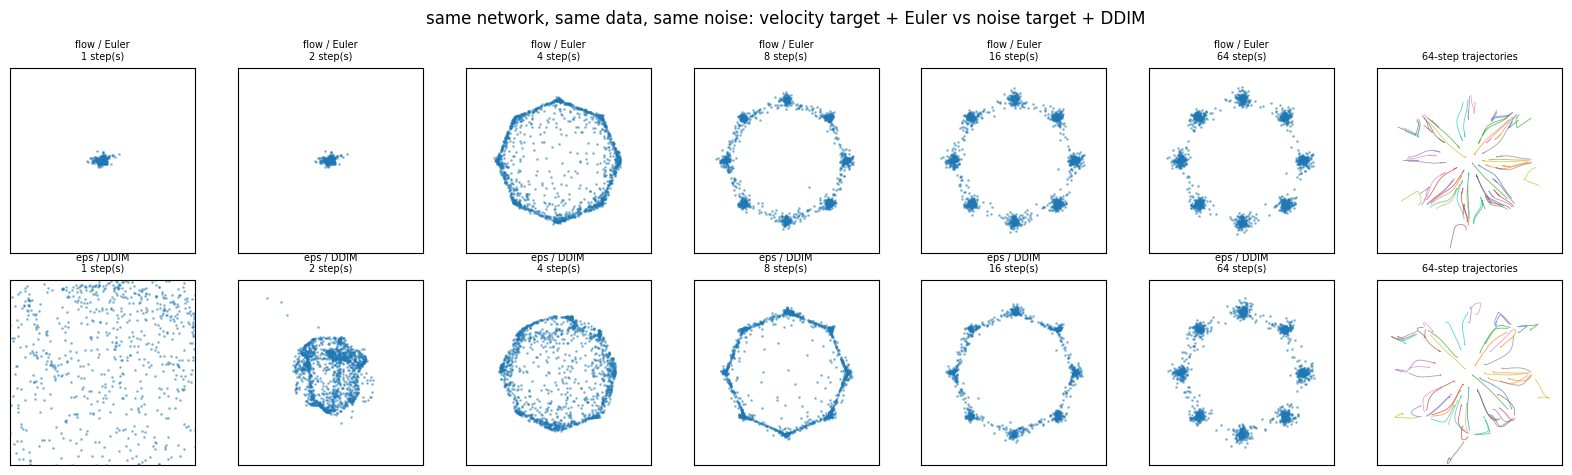

What to look at (full run; QUICK's 300 steps are too few to read): the step count at which each
row stops smearing points between the blobs, and how curved each trajectory is. Straighter paths
lose less to Euler's straight-line steps. Section 4 exploits that.


In [10]:
fig, ax = plt.subplots(2, len(STEP_GRID) + 1, figsize=(2.3 * (len(STEP_GRID) + 1), 4.8))
for r, (name, fn, net) in enumerate([("flow / Euler", sample_flow, NET_FLOW), ("eps / DDIM", sample_ddim, NET_EPS)]):
    for c, n in enumerate(STEP_GRID):
        xs, _ = fn(net, n, X_INIT[:1500])
        ax[r, c].scatter(xs[:, 0], xs[:, 1], s=1, alpha=0.4)
        ax[r, c].set_title(f"{name}\n{n} step(s)", fontsize=7)
    path = PATH_F if r == 0 else PATH_D
    for k in range(60):
        ax[r, -1].plot(path[:, k, 0], path[:, k, 1], lw=0.6, alpha=0.7)
    ax[r, -1].set_title("64-step trajectories", fontsize=7)
for a in ax.ravel():
    a.set_xlim(-3, 3); a.set_ylim(-3, 3); a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.suptitle("same network, same data, same noise: velocity target + Euler vs noise target + DDIM"); plt.tight_layout(); plt.show()
print("""What to look at (full run; QUICK's 300 steps are too few to read): the step count at which each
row stops smearing points between the blobs, and how curved each trajectory is. Straighter paths
lose less to Euler's straight-line steps. Section 4 exploits that.""")

**Why the paths are not perfectly straight.** Each *training* pair $(x_0, \varepsilon)$ is joined
by a straight line. But the network learns the **average** velocity over all pairs whose lines
pass through a point. Where lines from different blobs cross, that average bends. The random pairing of noise to data is what causes the curvature.

## 4. Rectified flow: reflow straightens the paths

Liu et al.'s **reflow** re-pairs the data: sample noise $\varepsilon$, integrate the trained model
to get *its* $\hat x_0(\varepsilon)$, and train a new flow on the pairs $(\hat x_0, \varepsilon)$.
These pairs come from a deterministic ODE, and ODE trajectories do not cross, so the straight
lines between the new pairs cross far less. The retrained flow is straighter, and few-step
sampling gets better. The price is bias: the new model learns the old model's samples, not the
data. (This is the idea behind few-step "rectified" and distilled models. We do not claim any
production model used exactly this procedure.)

In [11]:
PAIR_EPS = torch.randn(N_PAIRS, 2, generator=torch.Generator().manual_seed(321))
PAIR_X, _ = sample_flow(NET_FLOW, 64, PAIR_EPS)
NET_REFLOW = train_toy("flow", pairs=(PAIR_X, PAIR_EPS))
_, PATH_R = sample_flow(NET_REFLOW, 64, X_INIT[:400])
TOY["reflow"] = {}
for n in STEP_GRID:
    xr, _ = sample_flow(NET_REFLOW, n, X_INIT)
    TOY["reflow"][n] = {"swd": swd(xr, REF), "off": off_mode(xr)}
TOY["straightness"]["reflow"] = straightness(PATH_R)
print(f"{'steps':>6} | {'1-rectified SWD':>16} | {'2-rectified (reflow) SWD':>25}")
for n in STEP_GRID:
    print(f"{n:>6} | {TOY['flow'][n]['swd']:>16.4f} | {TOY['reflow'][n]['swd']:>25.4f}")
print(f"straightness: 1-rectified {TOY['straightness']['flow']:.3f}  ->  reflow {TOY['straightness']['reflow']:.3f}")
print(f"(reflow's floor is the SWD of its own training targets vs data: {swd(PAIR_X[:N_EVAL], REF):.4f})")

 steps |  1-rectified SWD |  2-rectified (reflow) SWD
     1 |           1.2340 |                    0.0541
     2 |           1.2342 |                    0.0540
     4 |           0.1570 |                    0.0487
     8 |           0.0678 |                    0.0468
    16 |           0.0512 |                    0.0462
    64 |           0.0442 |                    0.0458
straightness: 1-rectified 0.666  ->  reflow 0.998
(reflow's floor is the SWD of its own training targets vs data: 0.0386)


## 5. Timestep sampling and the shift

### 5.1 Which σ do we train on?

Uniform σ spends equal effort everywhere. The SD3 paper (Esser et al., 2024) compared several
densities and favoured **logit-normal**: $\sigma = \text{sigmoid}(u)$, $u \sim \mathcal N(m, s)$.
It concentrates on the middle, where the velocity is hardest to predict. In diffusers 0.40.0
this is `training_utils.compute_density_for_timestep_sampling("logit_normal", ...)`, which we
read: it returns `sigmoid(normal(logit_mean, logit_std))` (a `"mode"` scheme and a uniform
fallback also exist). The companion `compute_loss_weighting_for_sd3` returns `sigma**-2`
(`"sigma_sqrt"`), a `"cosmap"` weight, or ones.

### 5.2 The shift, and why resolution needs it

The **shift** $\alpha$ warps σ towards noise: $\sigma' = \dfrac{\alpha\sigma}{1 + (\alpha-1)\sigma}$.
Written in terms of the signal-to-noise ratio $\text{SNR}(\sigma) = (1-\sigma)^2/\sigma^2$, it is
simply

$$\text{SNR}(\sigma') = \text{SNR}(\sigma)\,/\,\alpha^2 .$$

Why higher resolution wants it: neighbouring pixels (and latents) are highly correlated. At a
fixed σ, an image with $m$ pixels gives the denoiser $m$ correlated noisy views of the same
low-frequency content. The coarse structure is therefore *easier* to recover than at $n < m$
pixels, as if the SNR were $m/n$ times higher. To make a 1024² model face the same difficulty at
a given σ as a 256² model, divide its SNR by $m/n$, which means $\alpha = \sqrt{m/n}$. The SD3
paper makes this argument (approximately as stated here). The cell below checks the identity
exactly, and checks the "$m$ views" argument by simulation.

In [12]:
shift_fn = lambda s, a: a * s / (1 + (a - 1) * s)
snr = lambda s: ((1 - s) / s) ** 2
sig = torch.linspace(0.02, 0.98, 49, dtype=torch.float64)
for a in (2.0, 3.0):
    assert torch.allclose(snr(shift_fn(sig, a)) * a**2, snr(sig)), "shift is not SNR / alpha^2"
print("identity verified: SNR(shift(sigma, a)) = SNR(sigma) / a^2")

# simulation: estimate a constant 'image' c from n noisy pixels at sigma; error of the mean estimate
gsim = torch.Generator().manual_seed(5)


def coarse_err(sigma, n, trials=400, c=0.7):
    x = (1 - sigma) * c + sigma * torch.randn(trials, n, generator=gsim, dtype=torch.float64)
    return float((x.mean(1) / (1 - sigma) - c).std())


n_lo, n_hi = 32 * 32, 64 * 64                      # 4x the pixels -> predicted alpha = 2
a_pred = math.sqrt(n_hi / n_lo)
print(f"\n{'sigma @ n':>10}{'err @ n':>10}{'err @ 4n, same sigma':>22}{'sigma shifted':>15}{'err @ 4n, shifted':>19}")
for s0 in (0.3, 0.5, 0.7, 0.9):
    s1 = shift_fn(torch.tensor(s0, dtype=torch.float64), a_pred).item()
    print(f"{s0:>10.2f}{coarse_err(s0, n_lo):>10.4f}{coarse_err(s0, n_hi):>22.4f}{s1:>15.3f}{coarse_err(s1, n_hi):>19.4f}")
print(f"-> at the same sigma, 4x the pixels halves the coarse-structure error; shifting by alpha = sqrt(4) = {a_pred:.0f} restores it.")

identity verified: SNR(shift(sigma, a)) = SNR(sigma) / a^2

 sigma @ n   err @ n  err @ 4n, same sigma  sigma shifted  err @ 4n, shifted
      0.30    0.0135                0.0072          0.462             0.0139
      0.50    0.0331                0.0149          0.667             0.0301
      0.70    0.0730                0.0366          0.824             0.0719
      0.90    0.2896                0.1458          0.947             0.2765
-> at the same sigma, 4x the pixels halves the coarse-structure error; shifting by alpha = sqrt(4) = 2 restores it.


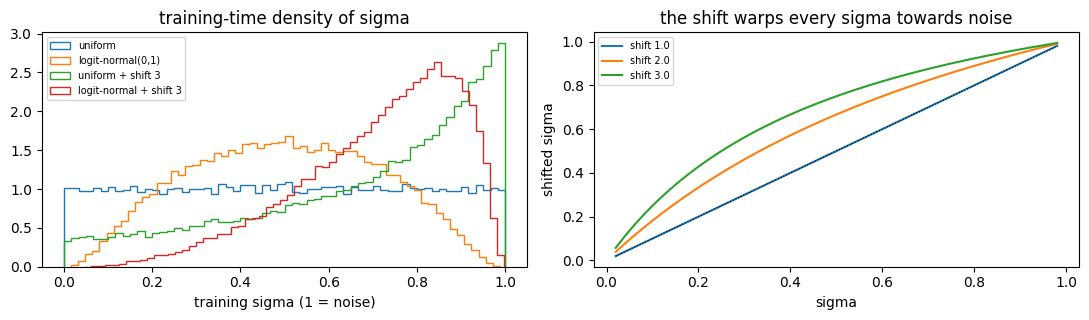

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
gd = torch.Generator().manual_seed(0)
for scheme, shift, lab in [("uniform", 1.0, "uniform"), ("logit_normal", 1.0, "logit-normal(0,1)"),
                           ("uniform", 3.0, "uniform + shift 3"), ("logit_normal", 3.0, "logit-normal + shift 3")]:
    ax[0].hist(sample_sigma(50000, scheme, shift, gd).numpy(), bins=60, density=True, histtype="step", label=lab)
ax[0].set_xlabel("training sigma (1 = noise)"); ax[0].legend(fontsize=7); ax[0].set_title("training-time density of sigma")
for a in (1.0, 2.0, 3.0):
    ax[1].plot(sig, shift_fn(sig, a), label=f"shift {a}")
ax[1].plot(sig, sig, "k:", lw=0.8); ax[1].set_xlabel("sigma"); ax[1].set_ylabel("shifted sigma"); ax[1].legend(fontsize=7)
ax[1].set_title("the shift warps every sigma towards noise")
plt.tight_layout(); plt.show()

### 5.3 A toy ablation, with the right expectation

The toy is 2-D, so it has no "resolution". The argument for the shift does not apply to it, and
the differences below should be small. A shifted model is *sampled* with the same shift it was
trained with.

In [14]:
ABL = {}
for scheme, shift in [("uniform", 1.0), ("logit_normal", 1.0), ("uniform", 3.0)]:
    net = train_toy("flow", scheme=scheme, shift=shift)
    ABL[f"{scheme}/shift{shift:g}"] = {n: swd(sample_flow(net, n, X_INIT, shift=shift)[0], REF) for n in (2, 8, 64)}
print(f"{'training density':<24}{'SWD@2':>9}{'SWD@8':>9}{'SWD@64':>9}")
for k, v in ABL.items():
    print(f"{k:<24}{v[2]:>9.4f}{v[8]:>9.4f}{v[64]:>9.4f}")
TOY["timestep_ablation"] = ABL
print("On 2-D data differences of this size are within seed noise: rerun with another SEED before believing any ordering.")

training density            SWD@2    SWD@8   SWD@64
uniform/shift1             1.2342   0.0678   0.0442
logit_normal/shift1        1.2181   0.0674   0.0473
uniform/shift3             1.2561   0.1062   0.0561
On 2-D data differences of this size are within seed noise: rerun with another SEED before believing any ordering.


### 5.4 How diffusers applies the shift: static, dynamic, and training vs inference

Read from `FlowMatchEulerDiscreteScheduler` in diffusers 0.40.0. Each claim below is asserted in
the next cell:

1. **Static `shift`** (config `shift`, `use_dynamic_shifting=False`) is applied twice over.
   `__init__` bakes it into the 1 000 training `sigmas`, and `set_timesteps(n)` applies it
   again to a `linspace(sigma_max, sigma_min, n)` built from those already-shifted endpoints.
   Only the low-noise end is affected, and only slightly. Consequence: **training code that samples
   timesteps by indexing `scheduler.timesteps` inherits the shift**, which is what SD3-style
   scripts do.
2. **Dynamic shifting** (config `use_dynamic_shifting=True`, with `base_shift`, `max_shift`,
   `base_image_seq_len`, `max_image_seq_len`, `time_shift_type`). `__init__` leaves the
   training sigmas **unshifted**. `set_timesteps(n, mu=...)` applies
   `exp(mu) / (exp(mu) + (1/t - 1))` for the default `"exponential"` type, which is the same map
   with $\alpha = e^{\mu}$. The pipelines compute `mu` with `calculate_shift(image_seq_len, ...)`,
   a straight line in the number of image tokens between `(base_image_seq_len, base_shift)` and
   `(max_image_seq_len, max_shift)`.
3. `shift_terminal` (Qwen-Image sets it) stretches the schedule so that it ends at that σ
   instead of near 0.

In [15]:
from diffusers.pipelines.stable_diffusion_3.pipeline_stable_diffusion_3 import calculate_shift

N_INF = 8
st = FlowMatchEulerDiscreteScheduler(shift=3.0)
dy = FlowMatchEulerDiscreteScheduler(use_dynamic_shifting=True)
flat = FlowMatchEulerDiscreteScheduler(shift=1.0)
assert torch.allclose(st.sigmas, shift_fn(flat.sigmas.double(), 3.0).float(), atol=1e-6), "static shift not baked into training sigmas"
assert torch.allclose(dy.sigmas, flat.sigmas), "dynamic-shift scheduler should leave training sigmas unshifted"
st.set_timesteps(N_INF)
dy.set_timesteps(N_INF, mu=math.log(3.0))
assert torch.allclose(st.sigmas[:-1], shift_fn(torch.linspace(st.sigma_max, st.sigma_min, N_INF, dtype=torch.float64), 3.0).float(), atol=1e-5)
assert torch.allclose(dy.sigmas[:-1], shift_fn(torch.linspace(dy.sigma_max, dy.sigma_min, N_INF, dtype=torch.float64), 3.0).float(), atol=1e-5)
print("verified: static shift is baked into training sigmas; dynamic shift = the same map with alpha = exp(mu)")
print(f"training-sigma median: static shift 3 -> {FlowMatchEulerDiscreteScheduler(shift=3.0).sigmas.median():.3f}   "
      f"dynamic (shift applied only at inference) -> {FlowMatchEulerDiscreteScheduler(use_dynamic_shifting=True).sigmas.median():.3f}")
print(f"last non-zero inference sigma, {N_INF} steps: static {st.sigmas[-2]:.5f} vs dynamic(mu=ln3) {dy.sigmas[-2]:.5f} "
      "(the static path shifts sigma_min twice)")

# Qwen-Image's own scheduler config (a small ungated JSON), then the shift it implies per resolution
from huggingface_hub import hf_hub_download, HfApi

QWEN_ID = "Qwen/Qwen-Image-2512"
QCFG = json.load(open(hf_hub_download(QWEN_ID, "scheduler/scheduler_config.json")))
QVAE = json.load(open(hf_hub_download(QWEN_ID, "vae/config.json")))
q_vsf = 2 ** len(QVAE["temperal_downsample"])          # QwenImagePipeline.vae_scale_factor
print(f"\n{QWEN_ID} scheduler: " + ", ".join(f"{k}={QCFG[k]}" for k in
      ["use_dynamic_shifting", "base_shift", "max_shift", "base_image_seq_len", "max_image_seq_len",
       "time_shift_type", "shift_terminal"]))
QWEN_SHIFT = {}
for px in (512, 1024):
    seq = (px // q_vsf // 2) ** 2                        # 2x2 latent packing (QwenImagePipeline._pack_latents)
    mu = calculate_shift(seq, QCFG["base_image_seq_len"], QCFG["max_image_seq_len"], QCFG["base_shift"], QCFG["max_shift"])
    QWEN_SHIFT[px] = {"tokens": seq, "mu": mu, "alpha": math.exp(mu)}
    print(f"   {px}x{px}: {seq} image tokens -> mu {mu:.4f} -> effective shift exp(mu) = {math.exp(mu):.3f}")
MEAS["qwen_shift"] = QWEN_SHIFT

verified: static shift is baked into training sigmas; dynamic shift = the same map with alpha = exp(mu)
training-sigma median: static shift 3 -> 0.750   dynamic (shift applied only at inference) -> 0.500
last non-zero inference sigma, 8 steps: static 0.00893 vs dynamic(mu=ln3) 0.00299 (the static path shifts sigma_min twice)


scheduler_config.json:   0%|          | 0.00/485 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]


Qwen/Qwen-Image-2512 scheduler: use_dynamic_shifting=True, base_shift=0.5, max_shift=0.9, base_image_seq_len=256, max_image_seq_len=8192, time_shift_type=exponential, shift_terminal=0.02
   512x512: 1024 image tokens -> mu 0.5387 -> effective shift exp(mu) = 1.714
   1024x1024: 4096 image tokens -> mu 0.6935 -> effective shift exp(mu) = 2.001


---

# Part 2: LoRA on a pretrained DiT with the flow-matching objective

## 6. Which DiT fits a 16 GB T4?

Weights only, at 2 bytes per parameter. All numbers come
from the Hub at run time: the parameter count and dtype from each safetensors header, where the
repo lets us read it, and file sizes otherwise. A gated repo only exposes its headers after you
accept its licence. Nothing is downloaded here.

In [16]:
api = HfApi()
VARIANT = re.compile(r"\.(fp16|bf16)[.-]")
COMPS = ["transformer", "text_encoder", "text_encoder_2", "text_encoder_3", "vae"]


def hub_components(repo):
    """{component: (params or None, dtypes or 'file size', bytes on disk)} without downloading weights."""
    info = api.model_info(repo, files_metadata=True)
    out = {}
    for c in COMPS:
        fs = [s for s in info.siblings if s.rfilename.startswith(c + "/") and s.rfilename.endswith(".safetensors")]
        main = [s for s in fs if not VARIANT.search(s.rfilename)] or fs
        if not main:
            continue
        size = sum(s.size or 0 for s in main)
        try:
            cnt = {}
            for s in main:
                for k, v in api.parse_safetensors_file_metadata(repo, s.rfilename).parameter_count.items():
                    cnt[k] = cnt.get(k, 0) + v
            out[c] = (sum(cnt.values()), "/".join(cnt), size)
        except Exception:                      # gated without access: headers unreadable
            out[c] = (None, "file size", size)
    cd = info.card_data.to_dict() if info.card_data else {}
    return out, {"gated": info.gated, "license": cd.get("license"), "license_name": cd.get("license_name")}


def comp_gb(c):
    """16-bit GB if the header gave a parameter count, else GB on disk."""
    return c[0] * 2 / 1e9 if c[0] is not None else c[2] / 1e9


CANDIDATES = ["stabilityai/stable-diffusion-3.5-medium", "stabilityai/stable-diffusion-3-medium-diffusers",
              "Efficient-Large-Model/Sana_600M_512px_diffusers", "black-forest-labs/FLUX.1-schnell",
              "black-forest-labs/FLUX.1-dev", QWEN_ID]
HUB = {}
print(f"{'repo':<50}{'gated':>7}  {'licence':<36}{'denoiser':>10}{'text enc.':>11}  source")
for r in CANDIDATES + ([PIPE_ID] if PIPE_ID not in CANDIDATES else []):
    try:
        comps, meta = hub_components(r)
    except Exception as e:
        print(f"{r:<50} unavailable ({type(e).__name__})"); continue
    den = comp_gb(comps["transformer"]) if "transformer" in comps else float("nan")
    te = sum(comp_gb(v) for k, v in comps.items() if k.startswith("text_encoder"))
    src = "headers" if all(v[0] is not None for v in comps.values()) else "disk size (gated)"
    lic = meta["license_name"] or meta["license"]
    HUB[r] = {"components": {k: {"params": v[0], "dtype": v[1], "bytes": v[2]} for k, v in comps.items()}, **meta}
    print(f"{r:<50}{str(meta['gated']):>7}  {str(lic)[:35]:<36}{den:>9.1f}G{te:>10.1f}G  {src}")
print(f"\nthis GPU: {TOTAL_VRAM_GB:.1f} GiB")
MEAS["hub"] = HUB

repo                                                gated  licence                               denoiser  text enc.  source
stabilityai/stable-diffusion-3.5-medium              auto  stabilityai-ai-community                  4.9G      11.2G  headers
stabilityai/stable-diffusion-3-medium-diffusers      auto  stabilityai-nc-research-community         4.2G      11.2G  disk size (gated)
Efficient-Large-Model/Sana_600M_512px_diffusers     False  apache-2.0                                1.2G       5.2G  headers
black-forest-labs/FLUX.1-schnell                     auto  apache-2.0                               23.8G       9.8G  headers
black-forest-labs/FLUX.1-dev                         auto  flux-1-dev-non-commercial-license        23.8G       9.8G  headers
Qwen/Qwen-Image-2512                                False  apache-2.0                               40.9G      16.6G  headers

this GPU: 22.0 GiB


Reading the table:

* **Qwen-Image (the desi-max base).** The denoiser alone exceeds a T4 in 16-bit, and so does
  its text encoder. It is out of reach without 4-bit quantisation *and* offloading, and still
  slow. We relate it to this notebook in §15 rather than run it.
* **Flux (12 B-class).** The same story at about half the size. It needs NF4 or a bigger card. Its licences differ: schnell is Apache-2.0, dev is
  non-commercial. Both are gated.
* **SD3.5-medium / SD3-medium.** The denoiser fits a T4 in fp16 with room for LoRA training. The
  text encoders, T5-XXL above all, are the other big block of memory, and §8 removes them from
  training entirely. SD3-medium's licence is non-commercial research. SD3.5-medium's is Stability's
  community licence, which has conditions: read it. **This is the smallest MMDiT we could verify
  that trains on a T4, so it is the full-run model.**
* **Sana-600M** is smaller still, Apache-2.0 and ungated, and also a flow-matching DiT. But it
  uses a different pipeline, VAE and attention design, so it is an exercise, not wired here.

> **fp16 on a T4 is the risk we cannot rule out statically.** SD3-medium publishes an explicit
> `fp16` variant. SD3.5-medium publishes one 16-bit file, whose dtype we cannot read without
> licence access. §10 and §11 assert that the transformer's outputs are finite on the first
> forward pass. If that fires on a T4, switch `PIPE_ID` to SD3-medium or use bf16 hardware.

In [17]:
from huggingface_hub.errors import GatedRepoError

try:
    api.auth_check(PIPE_ID)
except GatedRepoError as e:
    raise RuntimeError(f"{PIPE_ID} is gated: accept its licence on the Hub and set HF_TOKEN "
                       "(Kaggle: Add-ons -> Secrets), then rerun.") from e
print(f"access to {PIPE_ID}: ok")

access to stabilityai/stable-diffusion-3.5-medium: ok


## 7. Data: the matchbox labels (the curation workflow is notebook 55's)

Notebook 55 is the place for building a small style set: licence record, dedup, consistency
review, captioning *content, not style*, repeats and epochs, and checkpoint selection. None of that
changes with the objective, so it is not repeated here. This notebook trains on the same curated
folder, `matchbox_india`, and uses each image's hand-written `.txt` caption with the trigger first
(`phlmx, a matchbox label, ...`). Images smaller than the training resolution on their short side
are skipped rather than upscaled; at 768 px none of the 197 is. The number of steps is set so that
every training image is seen about 30 times, as in notebook 55 §6.

The in-training evaluation (§11, §12) scores four fixed prompts of everyday objects ("a ceramic
teapot", "a wooden chair", ...) that the labels never show. They measure whether the style
transfers to new subjects, not what the labels look like; §17 generates actual labels.


In [18]:
from datasets import load_dataset

# Your own images instead: FT_STYLE_DIR = a folder of .jpg/.jpeg/.png/.webp. Each image's
# content caption is read from a same-named .txt next to it (the kohya convention), else from its filename.
STYLE_DIR = os.environ.get("FT_STYLE_DIR") or None
RECS = []
if STYLE_DIR:
    dlic = os.environ.get("FT_STYLE_LICENCE", "").strip().lower() or "unspecified"   # recorded, not gated
    EXTS = {".jpg", ".jpeg", ".png", ".webp"}
    paths = sorted(q for q in Path(STYLE_DIR).rglob("*") if q.suffix.lower() in EXTS)
    assert paths, f"no .jpg/.jpeg/.png/.webp images found under {STYLE_DIR}"
    for q in paths:
        im = Image.open(q).convert("RGB")
        if min(im.size) < RES:              # never upscale
            continue
        side = q.with_suffix(".txt")
        desc = side.read_text(encoding="utf-8").strip() if side.exists() else q.stem.replace("_", " ")
        RECS.append({"img": im, "caption": f"{TRIGGER}, {desc}", "content": desc,
                     "record_id": q.relative_to(STYLE_DIR).as_posix()})
    print(f"{len(RECS)} usable images from {STYLE_DIR} (smaller than {RES}px on the short side are skipped)")
    assert len(RECS) >= 2, "need at least 2 usable images (1 train + 1 held-out)"
    random.Random(SEED).shuffle(RECS)          # the held-out set is a random sample, not the last files by name
    N_HOLD = min(N_HOLD, max(1, len(RECS) // 5))
    N_TRAIN = len(RECS) - N_HOLD               # a curated folder: train on all of it
    if not QUICK:
        MAX_STEPS = max(MAX_STEPS, math.ceil(TARGET_VIEWS * N_TRAIN / (BATCH * GRAD_ACC)))
        EVAL_EVERY = max(25, MAX_STEPS // 8)
    print(f"schedule: {MAX_STEPS} optimizer steps x {BATCH * GRAD_ACC} images = "
          f"{MAX_STEPS * BATCH * GRAD_ACC / N_TRAIN:.1f} views per training image; evaluated every {EVAL_EVERY} steps")
else:
    dinfo = api.dataset_info(DATA_ID)
    dlic = (dinfo.card_data.to_dict() if dinfo.card_data else {}).get("license")
    print(f"{DATA_ID}: licence {dlic}")
    assert dlic in ("cc0-1.0", ["cc0-1.0"]), "licence not cleared (notebook 55 §2.1)"

    ds = load_dataset(DATA_ID, split="train", streaming=True)
    for r in ds:
        im, desc = r.get("image"), (r.get("description") or "").strip()
        if im is None or len(desc.split()) < 5:
            continue
        im = im.convert("RGB")
        if min(im.size) < RES:              # never upscale
            continue
        RECS.append({"img": im, "caption": f"{TRIGGER}, {desc}", "content": desc, "record_id": r.get("record_id")})
        if len(RECS) >= N_TRAIN + N_HOLD:
            break
assert len(RECS) == N_TRAIN + N_HOLD, f"only {len(RECS)} usable rows"
TRAIN, HOLD = RECS[:N_TRAIN], RECS[N_TRAIN:]
print(f"train {len(TRAIN)}  held-out {len(HOLD)}   e.g. {TRAIN[0]['caption'][:110]!r}")

EVAL_PROMPTS = ["a ceramic teapot", "a wooden chair", "a brass door handle", "a woven basket"]
if QUICK:
    EVAL_PROMPTS = EVAL_PROMPTS[:2]

197 usable images from /content/desi_repo/finetune/notebooks/data/matchbox_india (smaller than 768px on the short side are skipped)
schedule: 1418 optimizer steps x 4 images = 30.0 views per training image; evaluated every 177 steps
train 189  held-out 8   e.g. "phlmx, a matchbox label, two red cherries on a stem with green leaves, yellow background, headline 'FRUITS', t"


## 8. Three text encoders: encode once, cache, free

SD3 conditions on **CLIP-L + OpenCLIP-bigG + T5-XXL**. `encode_prompt` in diffusers 0.40.0
returns `(prompt_embeds, negative_prompt_embeds, pooled_prompt_embeds, negative_pooled_prompt_embeds)`.
`prompt_embeds` is the two CLIP sequences concatenated on the feature axis and zero-padded to
T5's width, followed by the T5 sequence along the token axis: `77 + max_sequence_length` tokens of
`joint_attention_dim` features. The pooled vector concatenates the two CLIP poolings.

The encoders are frozen, so their outputs depend only on the captions. We load the pipeline
**without** a transformer or VAE (`transformer=None, vae=None`; the SD3 `__init__` tolerates
both), embed every caption and prompt we will ever use, and then drop the encoders. The trade-off: no caption dropout or caption augmentation
during training, because the embeddings are fixed.

**Numerics.** T5 is a known fp16 overflow risk. transformers 5.15.1 keeps T5's `wo` projections
in fp32 (`T5EncoderModel._keep_in_fp32_modules == ['wo']`, which we checked), and we still assert
that every embedding is finite.

In [19]:
from diffusers import StableDiffusion3Pipeline, SD3Transformer2DModel, AutoencoderKL

PIPE_COMPS = HUB.get(PIPE_ID, {}).get("components", {})     # empty if the §6 lookup failed: predictions become 0
pred_te = sum(v["params"] or v["bytes"] / 2 for k, v in PIPE_COMPS.items() if k.startswith("text_encoder")) * 2 / 2**30
if DEV == "cuda":
    torch.cuda.reset_peak_memory_stats()
t0 = time.perf_counter()
enc_pipe = StableDiffusion3Pipeline.from_pretrained(PIPE_ID, transformer=None, vae=None, dtype=DTYPE).to(DEV)
n_te = {k: sum(p.numel() for p in getattr(enc_pipe, k).parameters()) for k in ["text_encoder", "text_encoder_2", "text_encoder_3"]}
print({k: f"{v/1e6:.1f} M" for k, v in n_te.items()}, f"loaded in {time.perf_counter()-t0:.0f}s")


@torch.no_grad()
def encode(texts, bs=8):
    pe, pp = [], []
    for s in range(0, len(texts), bs):
        e, _, p, _ = enc_pipe.encode_prompt(prompt=texts[s:s + bs], prompt_2=None, prompt_3=None, device=DEV,
                                            num_images_per_prompt=1, do_classifier_free_guidance=False,
                                            max_sequence_length=MAX_SEQ)
        pe.append(e.to("cpu", torch.float16 if DEV == "cuda" else torch.float32))
        pp.append(p.to("cpu", torch.float16 if DEV == "cuda" else torch.float32))
    return torch.cat(pe), torch.cat(pp)


EMB = {"train": encode([r["caption"] for r in TRAIN]), "hold": encode([r["caption"] for r in HOLD]),
       "grid": encode([f"{TRIGGER}, {p}" for p in EVAL_PROMPTS]), "neg": encode([""])}
for k, (e, p) in EMB.items():
    assert torch.isfinite(e.float()).all() and torch.isfinite(p.float()).all(), f"non-finite '{k}' embeddings (fp16 overflow?)"
JOINT_DIM = EMB["train"][0].shape[-1]
print({k: (tuple(v[0].shape), tuple(v[1].shape)) for k, v in EMB.items()})
print(f"prompt_embeds tokens = 77 (CLIP) + {MAX_SEQ} (T5) = {EMB['train'][0].shape[1]}; width {JOINT_DIM}")
peak_te = torch.cuda.max_memory_allocated() / 2**30 if DEV == "cuda" else 0.0
MEAS["text_encoders"] = {"params": n_te, "predicted_gib": pred_te, "peak_gib": peak_te}
print(f"text-encoder stage: predicted weights {pred_te:.2f} GiB (16-bit), measured peak {peak_te:.2f} GiB "
      "(gap = activations of one encode batch + CUDA context)")

cache_mb = sum(v.numel() * v.element_size() for e in EMB.values() for v in e) / 1e6
del enc_pipe
free_mem()
print(f"text encoders freed; {cache_mb:.1f} MB of cached embeddings replace "
      f"{sum(n_te.values())/1e9:.2f} B encoder params for the rest of the notebook.")

model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

{'text_encoder': '123.7 M', 'text_encoder_2': '694.7 M', 'text_encoder_3': '4762.3 M'} loaded in 41s
{'train': ((189, 333, 4096), (189, 2048)), 'hold': ((8, 333, 4096), (8, 2048)), 'grid': ((4, 333, 4096), (4, 2048)), 'neg': ((1, 333, 4096), (1, 2048))}
prompt_embeds tokens = 77 (CLIP) + 256 (T5) = 333; width 4096
text-encoder stage: predicted weights 10.39 GiB (16-bit), measured peak 10.94 GiB (gap = activations of one encode batch + CUDA context)
text encoders freed; 551.9 MB of cached embeddings replace 5.58 B encoder params for the rest of the notebook.


## 9. Latents

SD3's VAE has 16 latent channels and **both** a `scaling_factor` and a `shift_factor`. The
pipeline decodes with `latents / scaling_factor + shift_factor`, so encoding must be the
inverse: `(z - shift_factor) * scaling_factor`. Get this wrong and training "works", but it
learns latents the pipeline will never produce. We encode in **fp32**, since the VAE is small,
and later decode ourselves in fp32. The SD3 pipeline does not cast latents to the VAE's dtype,
so we ask it for `output_type="latent"`.

In [20]:
from torchvision.transforms import functional as TF

vae = AutoencoderKL.from_pretrained(PIPE_ID, subfolder="vae", dtype=torch.float32).to(DEV).eval()
vae.requires_grad_(False)
SF, SHIFT_F = vae.config.scaling_factor, (vae.config.shift_factor or 0.0)
VSF = 2 ** (len(vae.config.block_out_channels) - 1)
print(f"VAE: {vae.config.latent_channels} channels, x{VSF} downsample, scaling {SF}, shift {SHIFT_F}")


# Aspect-ratio buckets (notebook 55 §4): a square centre crop would cut a tall label's headline and maker
# line, which carry much of the style. Each image trains at the bucket closest to its aspect ratio,
# with about RES x RES pixels; sides are multiples of 64 (VAE x8 times patch 2, with margin).
def make_buckets(base, step=64, lo=0.5, hi=2.0):
    out = set()
    for w in range(step, 2 * base + 1, step):
        h = int(base * base / w) // step * step
        if h >= step and lo <= w / h <= hi:
            out.add((w, h))
    return sorted(out)


BUCKETS = [(RES, RES)] if QUICK else make_buckets(RES)


def assign(size):
    return min(BUCKETS, key=lambda b: abs(math.log(b[0] / b[1]) - math.log(size[0] / size[1])))


def to_px(im, bucket=None):
    bw, bh = bucket or (RES, RES)
    w, h = im.size
    s = max(bw / w, bh / h)
    im = im.resize((max(bw, round(w * s)), max(bh, round(h * s))), Image.LANCZOS)
    l, t = (im.size[0] - bw) // 2, (im.size[1] - bh) // 2
    return TF.to_tensor(im.crop((l, t, l + bw, t + bh))) * 2 - 1


@torch.no_grad()
def encode_latents(recs, seed=SEED):
    """One latent per image, each [1, C, h, w] at its own bucket (a list, since shapes differ)."""
    g = torch.Generator(DEV).manual_seed(seed)
    return [((vae.encode(to_px(r["img"], assign(r["img"].size))[None].to(DEV)).latent_dist.sample(generator=g)
              - SHIFT_F) * SF).cpu() for r in recs]


@torch.no_grad()
def decode(lats):
    ims = []
    for chunk in lats.split(4):
        x = vae.decode(chunk.to(DEV, torch.float32) / SF + SHIFT_F).sample
        arr = ((x.clamp(-1, 1) + 1) * 127.5).round().byte().permute(0, 2, 3, 1).cpu().numpy()
        ims += [Image.fromarray(a) for a in arr]
    return ims


TRAIN_LAT, HOLD_LAT = encode_latents(TRAIN), encode_latents(HOLD, seed=SEED + 1)
assert all(torch.isfinite(t).all() for t in TRAIN_LAT + HOLD_LAT), "non-finite latents"
TRAIN_BK = [tuple(t.shape[-2:]) for t in TRAIN_LAT]
BY_BUCKET = {k: [i for i, b in enumerate(TRAIN_BK) if b == k] for k in set(TRAIN_BK)}
print(f"{len(BY_BUCKET)} aspect buckets in use (latent h x w: count): "
      f"{dict(sorted((k, len(v)) for k, v in BY_BUCKET.items()))}")
rt = decode(TRAIN_LAT[0])[0]
err = float((TF.to_tensor(rt) * 2 - 1 - to_px(TRAIN[0]["img"], assign(TRAIN[0]["img"].size))).abs().mean())
_all = torch.cat([t.flatten(2) for t in TRAIN_LAT], dim=2)
print(f"latents e.g. {tuple(TRAIN_LAT[0].shape)}   mean per-channel std {_all.std((0, 2)).mean():.3f} "
      "(shift/scale exist to bring this near unit scale; far from 1 = suspect the encode formula)   "
      f"VAE round-trip |err| {err:.3f} (QUICK's random VAE: meaningless)")

config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  168MB            

vae/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

VAE: 16 channels, x8 downsample, scaling 1.5305, shift 0.0609
6 aspect buckets in use (latent h x w: count): {(72, 120): 23, (80, 112): 37, (96, 96): 1, (104, 88): 9, (112, 80): 103, (128, 72): 16}
latents e.g. (1, 16, 112, 80)   mean per-channel std 0.917 (shift/scale exist to bring this near unit scale; far from 1 = suspect the encode formula)   VAE round-trip |err| 0.032 (QUICK's random VAE: meaningless)


## 10. Inside the transformer: patchify, adaLN, joint attention, and the LoRA targets

Three ideas, read off the loaded model:

* **Patchify.** `pos_embed` is a `PatchEmbed`: a strided conv turns the latent (C × H × W) into
  $(H/p)(W/p)$ tokens. Attention cost grows with the square of (image tokens + text tokens).
* **adaLN.** Each block's `norm1` (and `norm1_context`) is an `AdaLayerNormZero`. A linear layer
  maps the timestep + pooled-text embedding to per-channel shift, scale and **gate** values. In
  the DiT paper (Peebles & Xie) the gates start at zero, so each block starts as the identity
  (the same idea as LoRA's zero-initialised `lora_B`).
* **Joint attention (MMDiT).** A `JointTransformerBlock` keeps **two streams** with separate
  weights: image tokens through `to_q/to_k/to_v/to_out.0`, text tokens through
  `add_q_proj/add_k_proj/add_v_proj/to_add_out`. It concatenates them for **one** attention.
  There is no cross-attention layer. Text and image attend to each other symmetrically. The last
  block is `context_pre_only`: its text stream feeds attention and is then discarded, so it has
  no `to_add_out` (diffusers' `Attention` sets `to_add_out = None` there).

In [21]:
_tc = PIPE_COMPS.get("transformer", {"params": None, "bytes": 0})
pred_dit = _tc["params"] or _tc["bytes"] / 2
transformer = SD3Transformer2DModel.from_pretrained(PIPE_ID, subfolder="transformer", dtype=DTYPE).to(DEV)
transformer.requires_grad_(False)
tcfg = transformer.config
n_dit = sum(p.numel() for p in transformer.parameters())
print(f"SD3Transformer2DModel: {n_dit/1e6:.1f} M params (header said {pred_dit/1e6:.1f} M)   layers {tcfg.num_layers}   "
      f"hidden {tcfg.num_attention_heads}x{tcfg.attention_head_dim}   patch {tcfg.patch_size}   "
      f"dual_attention_layers {tuple(tcfg.dual_attention_layers)}   qk_norm {tcfg.qk_norm}")
lat_side = RES // VSF
N_IMG_TOK = (lat_side // tcfg.patch_size) ** 2
N_TXT_TOK = EMB["train"][0].shape[1]
print(f"at {RES}px: latent {lat_side}x{lat_side} -> {N_IMG_TOK} image tokens + {N_TXT_TOK} text tokens "
      f"= {N_IMG_TOK + N_TXT_TOK} in every joint attention  (at 2x the resolution: {4*N_IMG_TOK} image tokens)")


def group_of(name):
    if name.startswith(("pos_embed", "time_text_embed", "context_embedder")):
        return "embedders (patchify, t + pooled text, caption proj)"
    if ".norm1" in name or name.startswith("norm_out"):
        return "adaLN modulation linears"
    if ".attn2." in name:
        return "attn2 (SD3.5 dual attention, image only)"
    if re.search(r"\.attn\.(add_[qkv]_proj|to_add_out)", name):
        return "joint attn: TEXT stream (add_*, to_add_out)"
    if re.search(r"\.attn\.(to_[qkv]|to_out)", name):
        return "joint attn: IMAGE stream (to_q/k/v/out)"
    if ".ff_context." in name:
        return "MLP: text stream"
    if ".ff." in name:
        return "MLP: image stream"
    return "other (proj_out, ...)"


groups = {}
for n, m in transformer.named_modules():
    if isinstance(m, nn.Linear) or n.endswith("pos_embed.proj"):
        k = group_of(n)
        c, p = groups.get(k, (0, 0))
        groups[k] = (c + 1, p + sum(q.numel() for q in m.parameters()))
for k, (c, p) in sorted(groups.items(), key=lambda kv: -kv[1][1]):
    print(f"   {k:<52}{c:>5} layers {p/1e6:>10.2f} M params")
print("adaLN block types:", sorted({type(m).__name__ for n, m in transformer.named_modules() if n.endswith("norm1")}))

CANDIDATE_TARGETS = ["to_q", "to_k", "to_v", "to_out.0", "add_q_proj", "add_k_proj", "add_v_proj", "to_add_out"]
linear_names = [n for n, m in transformer.named_modules() if isinstance(m, nn.Linear)]
LORA_TARGETS = [t for t in CANDIDATE_TARGETS if any(n.endswith("." + t) for n in linear_names)]
missing = sorted(set(CANDIDATE_TARGETS) - set(LORA_TARGETS))
print(f"\nLoRA targets present in this transformer: {LORA_TARGETS}")
print(f"absent: {missing or 'none'}   (the tiny 1-layer pipe has only a context_pre_only block -> no to_add_out)")
N_TARGET_LAYERS = sum(1 for n in linear_names if any(n.endswith("." + t) for t in LORA_TARGETS))
print(f"{N_TARGET_LAYERS} Linear layers will get an adapter (attention only; MLPs and adaLN left frozen: exercise 3)")

config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…): reconstructing file:   0%|          |  0.00B / 4.94GB            

transformer/diffusion_pytorch_model.safe(…): downloading bytes:           |  0.00B            

SD3Transformer2DModel: 2243.2 M params (header said 2469.7 M)   layers 24   hidden 24x64   patch 2   dual_attention_layers (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)   qk_norm rms_norm
at 768px: latent 96x96 -> 2304 image tokens + 333 text tokens = 2637 in every joint attention  (at 2x the resolution: 9216 image tokens)
   adaLN modulation linears                               49 layers     767.27 M params
   MLP: image stream                                     48 layers     453.17 M params
   MLP: text stream                                      46 layers     434.29 M params
   joint attn: IMAGE stream (to_q/k/v/out)               96 layers     226.64 M params
   joint attn: TEXT stream (add_*, to_add_out)           95 layers     224.28 M params
   attn2 (SD3.5 dual attention, image only)               52 layers     122.76 M params
   embedders (patchify, t + pooled text, caption proj)     6 layers      14.66 M params
   other (proj_out, ...)                                   1 layer

## 11. The inference pipeline without text encoders, and the baseline

The generation pipeline is assembled from the cached-embedding world: the transformer, a fresh
copy of the scheduler, the VAE, and `None` for all three encoders and tokenizers. The SD3
`__call__` accepts `prompt_embeds`, `pooled_prompt_embeds` and their negatives directly, and it
only touches the encoders when those are missing.

Two evaluations, both before training (measure the thing, not the loss):

1. **Held-out velocity error at fixed σ.** The held-out images are noised at five fixed σ with
   fixed noise and scored with the flow-matching MSE. The training loss is dominated by the random
   σ. Fixing σ and the noise removes that randomness,
   so this number *is* comparable across checkpoints. It measures fit to held-out images of the
   target distribution, not image quality.
2. **A fixed-seed sample grid** on prompts the data never contained, scored with CLIP: *style* is
   the cosine to the held-out image centroid, *adherence* the cosine to the content prompt
   (as in notebook 55 §7).

scheduler config: {'shift': 3.0, 'use_dynamic_shifting': False, 'num_train_timesteps': 1000}
training sigma median 0.750 (0.5 if unshifted; higher = static shift baked in, §5.4)


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

BASELINE  held-out velocity MSE per sigma {0.1: np.float64(0.5022), 0.3: np.float64(0.2286), 0.5: np.float64(0.1895), 0.7: np.float64(0.2078), 0.9: np.float64(0.365)}
          CLIP style 0.5802  adherence 0.3263   11.2 s/image at 28 steps


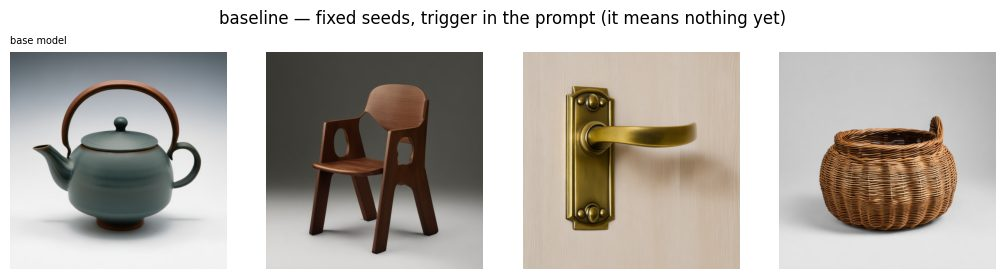

In [22]:
sched_infer = FlowMatchEulerDiscreteScheduler.from_pretrained(PIPE_ID, subfolder="scheduler")
train_sched = FlowMatchEulerDiscreteScheduler.from_config(sched_infer.config)   # never set_timesteps()!
print("scheduler config:", {k: sched_infer.config[k] for k in ["shift", "use_dynamic_shifting", "num_train_timesteps"]})
print(f"training sigma median {train_sched.sigmas.median():.3f} (0.5 if unshifted; higher = static shift baked in, §5.4)")


def make_pipe(tr):
    return StableDiffusion3Pipeline(transformer=tr, scheduler=FlowMatchEulerDiscreteScheduler.from_config(sched_infer.config),
                                    vae=vae, text_encoder=None, tokenizer=None, text_encoder_2=None,
                                    tokenizer_2=None, text_encoder_3=None, tokenizer_3=None)


@torch.no_grad()
def generate(p, key="grid", seed=SEED, scale=None):
    """Fixed CPU generators per image: identical initial noise across checkpoints, scales and pipelines."""
    pe, pp = EMB[key]
    ne, npp = EMB["neg"]
    xa = None if scale is None else {"scale": float(scale)}
    out = []
    for s in range(0, len(pe), GEN_BS):
        n = len(pe[s:s + GEN_BS])
        gens = [torch.Generator("cpu").manual_seed(seed + s + i) for i in range(n)]
        with torch.autocast("cuda", dtype=DTYPE, enabled=AMP):
            lat = p(prompt_embeds=pe[s:s + n].to(DEV, DTYPE), pooled_prompt_embeds=pp[s:s + n].to(DEV, DTYPE),
                    negative_prompt_embeds=ne.expand(n, -1, -1).to(DEV, DTYPE),
                    negative_pooled_prompt_embeds=npp.expand(n, -1).to(DEV, DTYPE),
                    height=RES, width=RES, num_inference_steps=GEN_STEPS, guidance_scale=GUIDANCE,
                    generator=gens, output_type="latent", joint_attention_kwargs=xa).images
        out.append(lat.float().cpu())
    return torch.cat(out)


EVAL_SIGMAS = [0.1, 0.3, 0.5, 0.7, 0.9]


@torch.no_grad()
def heldout_vel_err(tr, scale=None):
    """Flow-matching MSE on HELD-OUT latents at fixed sigmas with fixed noise: comparable across checkpoints."""
    was_training = tr.training
    tr.eval()
    g = torch.Generator("cpu").manual_seed(1234)
    xa = None if scale is None else {"scale": float(scale)}
    tot = np.zeros(len(EVAL_SIGMAS))
    for i in range(len(HOLD_LAT)):
        x0 = HOLD_LAT[i].to(DEV)
        noise = torch.randn(x0.shape, generator=g).to(DEV)
        for j, s in enumerate(EVAL_SIGMAS):
            xt = (1 - s) * x0 + s * noise
            with torch.autocast("cuda", dtype=DTYPE, enabled=AMP):
                v = tr(hidden_states=xt.to(DTYPE), timestep=torch.full((1,), s * 1000.0, device=DEV),
                       encoder_hidden_states=EMB["hold"][0][i:i + 1].to(DEV, DTYPE),
                       pooled_projections=EMB["hold"][1][i:i + 1].to(DEV, DTYPE),
                       joint_attention_kwargs=xa, return_dict=False)[0]
            assert torch.isfinite(v).all(), f"non-finite transformer output at sigma={s} ({DTYPE}): see §6's fp16 note"
            tot[j] += F.mse_loss(v.float(), noise - x0).item()
    tr.train(was_training)
    return (tot / len(HOLD_LAT)).tolist()


from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained(CLIP_ID, dtype=torch.float16 if DEV == "cuda" else torch.float32).to(DEV).eval()
cproc = CLIPProcessor.from_pretrained(CLIP_ID)


def _feat(o):
    # transformers 5.x returns BaseModelOutputWithPooling (projection in .pooler_output), 4.x a tensor
    return o.pooler_output if hasattr(o, "pooler_output") else o


@torch.no_grad()
def clip_img(imgs):
    px = cproc(images=[i.convert("RGB") for i in imgs], return_tensors="pt")["pixel_values"].to(DEV, clip.dtype)
    return F.normalize(_feat(clip.get_image_features(pixel_values=px)).float(), dim=-1).cpu()


@torch.no_grad()
def clip_txt(texts):
    t = cproc(text=texts, return_tensors="pt", padding=True, truncation=True)
    o = clip.get_text_features(input_ids=t["input_ids"].to(DEV), attention_mask=t["attention_mask"].to(DEV))
    return F.normalize(_feat(o).float(), dim=-1).cpu()


STYLE_C = F.normalize(clip_img([r["img"] for r in HOLD]).mean(0), dim=0)
T_PROMPTS = clip_txt(EVAL_PROMPTS)


def clip_scores(imgs):
    E = clip_img(imgs)
    return {"style": float((E @ STYLE_C).mean()), "adherence": float((E * T_PROMPTS).sum(-1).mean())}


def sheet(rows, titles, suptitle):
    fig, ax = plt.subplots(len(rows), len(rows[0]), figsize=(2.6 * len(rows[0]), 2.8 * len(rows)), squeeze=False)
    for i, row in enumerate(rows):
        for j, im in enumerate(row):
            ax[i, j].imshow(im); ax[i, j].axis("off")
            ax[i, j].set_title(titles[i] if j == 0 else "", fontsize=7, loc="left")
    plt.suptitle(suptitle); plt.tight_layout(); plt.show()


gen_pipe = make_pipe(transformer)
gen_pipe.set_progress_bar_config(disable=True)
t0 = time.perf_counter()
BASE_LAT = generate(gen_pipe)
GEN_SEC = (time.perf_counter() - t0) / len(BASE_LAT)
BASE_IMGS = decode(BASE_LAT)
BASE = {"heldout_vel_err": heldout_vel_err(transformer), **clip_scores(BASE_IMGS)}
print(f"BASELINE  held-out velocity MSE per sigma {dict(zip(EVAL_SIGMAS, np.round(BASE['heldout_vel_err'], 4)))}")
print(f"          CLIP style {BASE['style']:.4f}  adherence {BASE['adherence']:.4f}   {GEN_SEC:.1f} s/image at {GEN_STEPS} steps")
sheet([BASE_IMGS], ["base model"], "baseline: fixed seeds, trigger in the prompt (it means nothing yet)")
MEAS["baseline"] = BASE

## 12. Train: LoRA with the flow-matching loss

The step, with each diffusers 0.40.0 helper read from its source:

```python
u         = compute_density_for_timestep_sampling("logit_normal", B, logit_mean=0, logit_std=1)  # in (0, 1)
idx       = (u * 1000).long()
timesteps = train_sched.timesteps[idx]          # INHERITS a static config shift (§5.4)
sigmas    = train_sched.sigmas[idx]
x_t       = (1 - sigmas) * x0 + sigmas * noise  # == train_sched.scale_noise(x0, timesteps, noise)
v_hat     = transformer(x_t, timestep=timesteps, encoder_hidden_states=..., pooled_projections=...)
loss      = mean( compute_loss_weighting_for_sd3(scheme, sigmas) * (v_hat - (noise - x0))**2 )
```

Everything else is a standard diffusion-LoRA recipe: frozen 16-bit base, **fp32 LoRA params**
(`cast_training_params`), `torch.amp.GradScaler` for fp16, gradient checkpointing, and cached latents and embeddings. Pre-flight assertions: `lora_B`
is zero at init, only LoRA parameters train, our $x_t$ equals `scale_noise`, the first output is
finite, and gradients reach the adapter.

Keep `train_sched` and the inference scheduler separate. `set_timesteps()` overwrites
`scheduler.timesteps` with the n inference steps, so indexing it at `u * 1000` afterwards would
read out of range or from the wrong schedule. The assertion below catches that.

In [23]:
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from diffusers.training_utils import cast_training_params
from diffusers.optimization import get_scheduler

N_T = train_sched.config.num_train_timesteps
assert len(train_sched.timesteps) == N_T, "train_sched was set_timesteps()'d: its timesteps are an inference grid"

transformer.enable_gradient_checkpointing()
lora_cfg = LoraConfig(r=RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=LORA_TARGETS)
transformer.add_adapter(lora_cfg)
cast_training_params(transformer, dtype=torch.float32)          # LoRA params fp32; base stays DTYPE
params = [p for p in transformer.parameters() if p.requires_grad]
N_LORA = sum(1 for n, _ in transformer.named_modules() if n.endswith("lora_A.default"))
n_tr = sum(p.numel() for p in params)
assert N_LORA == N_TARGET_LAYERS, f"{N_LORA} adapters attached, expected {N_TARGET_LAYERS}"
assert all("lora_" in n for n, p in transformer.named_parameters() if p.requires_grad), "non-LoRA params are trainable"
assert all(p.dtype == torch.float32 for p in params), "fp16 trainable params break the GradScaler"
assert max(p.abs().max().item() for n, p in transformer.named_parameters() if "lora_B" in n) == 0.0, "lora_B != 0 at init"
print(f"{N_LORA} LoRA layers, {n_tr/1e6:.2f} M trainable params ({100*n_tr/n_dit:.3f}% of the transformer)")

# predict -> measure: static bytes now, activations measured below
pred_static = n_dit * torch.finfo(DTYPE).bits / 8 + n_tr * (4 + 4 + 8)      # base + fp32 LoRA param/grad/Adam m,v
print(f"predicted static training memory: {pred_static/2**30:.2f} GiB (weights + LoRA state); activations come on top")

opt = torch.optim.AdamW(params, lr=LR, betas=(0.9, 0.999), weight_decay=1e-4)
lr_sched = get_scheduler("cosine", optimizer=opt, num_warmup_steps=max(1, MAX_STEPS // 20), num_training_steps=MAX_STEPS)
scaler = torch.amp.GradScaler("cuda", enabled=(AMP and DTYPE == torch.float16))
rng = random.Random(SEED)
g_noise = torch.Generator(DEV).manual_seed(SEED)
LOG, EVALS, SHEETS, CKPTS = [], {}, {}, {}
if DEV == "cuda":
    torch.cuda.reset_peak_memory_stats()
transformer.train()
step, t0, checked = 0, time.perf_counter(), False
while step < MAX_STEPS:
    for _ in range(GRAD_ACC):
        i0 = rng.randrange(N_TRAIN)                 # one image, then batch-mates from its bucket
        b = [i0] + [rng.choice(BY_BUCKET[TRAIN_BK[i0]]) for _ in range(BATCH - 1)]
        x0 = torch.cat([TRAIN_LAT[i] for i in b]).to(DEV)
        noise = torch.randn(x0.shape, generator=g_noise, device=DEV)
        u = compute_density_for_timestep_sampling(WEIGHTING, BATCH, logit_mean=0.0, logit_std=1.0, device="cpu")
        ind = (u * N_T).long().clamp(0, N_T - 1)
        timesteps = train_sched.timesteps[ind].to(DEV)
        sigmas = train_sched.sigmas[ind].to(DEV).view(-1, 1, 1, 1)
        noisy = (1 - sigmas) * x0 + sigmas * noise
        if not checked:
            assert torch.allclose(noisy, train_sched.scale_noise(x0, timesteps, noise), atol=1e-5), "x_t != scale_noise"
        with torch.autocast("cuda", dtype=DTYPE, enabled=AMP):
            pred = transformer(hidden_states=noisy.to(DTYPE), timestep=timesteps,
                               encoder_hidden_states=EMB["train"][0][b].to(DEV, DTYPE),
                               pooled_projections=EMB["train"][1][b].to(DEV, DTYPE), return_dict=False)[0]
        if not checked:
            assert torch.isfinite(pred).all(), f"non-finite transformer output in {DTYPE}: see §6's fp16 note"
        target = noise - x0                                             # the velocity (§2)
        w = compute_loss_weighting_for_sd3(LOSS_WEIGHTING, sigmas)
        per = (w.float() * (pred.float() - target) ** 2).mean(dim=(1, 2, 3))
        loss = per.mean() / GRAD_ACC
        scaler.scale(loss).backward()
        LOG += [{"step": step, "sigma": float(s), "loss": float(l)} for s, l in zip(sigmas.flatten(), per.detach())]
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    if not checked:   # an fp16 overflow step has inf grads, which != 0 also catches; zero grads are the bug
        assert any(p.grad is not None and bool((p.grad != 0).any()) for p in params), "no gradient reaches LoRA"
        checked = True
    scaler.step(opt); scaler.update(); lr_sched.step()
    opt.zero_grad(set_to_none=True)
    step += 1
    if step % EVAL_EVERY == 0 or step == MAX_STEPS:
        transformer.eval()
        imgs = decode(generate(gen_pipe))
        EVALS[step] = {"heldout_vel_err": heldout_vel_err(transformer), **clip_scores(imgs)}
        SHEETS[step] = imgs
        CKPTS[step] = {n: p.detach().cpu().clone() for n, p in transformer.named_parameters() if p.requires_grad}
        transformer.train()
        print(f"  step {step:>4}/{MAX_STEPS}  held-out vel-MSE {np.mean(EVALS[step]['heldout_vel_err']):.4f} "
              f"(base {np.mean(BASE['heldout_vel_err']):.4f})  style {EVALS[step]['style']:.4f}  "
              f"adherence {EVALS[step]['adherence']:.4f}")
train_sec = time.perf_counter() - t0
peak = torch.cuda.max_memory_allocated() / 2**30 if DEV == "cuda" else 0.0
print(f"\n{step} optimizer steps in {train_sec/60:.1f} min ({train_sec/max(1, step):.2f} s/step incl. evals)")
print(f"peak {peak:.2f} GiB vs predicted static {pred_static/2**30:.2f} GiB -> activations/workspace ≈ "
      f"{max(0.0, peak - pred_static/2**30):.2f} GiB for {BATCH} x {N_IMG_TOK + N_TXT_TOK} tokens with checkpointing")

# Checkpoint selection (notebook 55 §9): the final step is not automatically the best. Eligible: prompt
# adherence within 0.02 of the base model, and held-out velocity error no worse than the base (a
# rising held-out error is the flow-matching overfitting signal, §13). Of those, the highest style.
_vel = {s: float(np.mean(e["heldout_vel_err"])) for s, e in EVALS.items()}
elig = [s for s in EVALS if EVALS[s]["adherence"] >= BASE["adherence"] - 0.02
        and _vel[s] <= float(np.mean(BASE["heldout_vel_err"]))]
BEST_STEP = max(elig or list(EVALS), key=lambda s: EVALS[s]["style"])
with torch.no_grad():
    for n, p in transformer.named_parameters():
        if n in CKPTS[BEST_STEP]:
            p.copy_(CKPTS[BEST_STEP][n].to(p.device, p.dtype))
for s in sorted(EVALS):
    print(f"  step {s:>5}: style {EVALS[s]['style']:.4f}  adherence {EVALS[s]['adherence']:.4f}  "
          f"held-out vel-MSE {_vel[s]:.4f}{'  <- selected' if s == BEST_STEP else ''}"
          f"{'' if s in elig else '  (not eligible)'}")
print(f"selected step {BEST_STEP} of {step}: its LoRA weights are now loaded and are what §14 saves")
MEAS["train"] = {"steps": step, "seconds": train_sec, "peak_gib": peak, "pred_static_gib": pred_static / 2**30,
                 "lora_layers": N_LORA, "trainable": n_tr, "evals": EVALS, "best_step": BEST_STEP,
                 "views_per_image": step * BATCH * GRAD_ACC / N_TRAIN}
del CKPTS

243 LoRA layers, 11.94 M trainable params (0.532% of the transformer)
predicted static training memory: 4.36 GiB (weights + LoRA state); activations come on top
  step  177/1418  held-out vel-MSE 0.2917 (base 0.2986)  style 0.5879  adherence 0.3274
  step  354/1418  held-out vel-MSE 0.2903 (base 0.2986)  style 0.5870  adherence 0.3333
  step  531/1418  held-out vel-MSE 0.2897 (base 0.2986)  style 0.5878  adherence 0.3289
  step  708/1418  held-out vel-MSE 0.2894 (base 0.2986)  style 0.5836  adherence 0.3253
  step  885/1418  held-out vel-MSE 0.2889 (base 0.2986)  style 0.5881  adherence 0.3337
  step 1062/1418  held-out vel-MSE 0.2886 (base 0.2986)  style 0.5854  adherence 0.3324
  step 1239/1418  held-out vel-MSE 0.2885 (base 0.2986)  style 0.5892  adherence 0.3284
  step 1416/1418  held-out vel-MSE 0.2885 (base 0.2986)  style 0.5920  adherence 0.3282
  step 1418/1418  held-out vel-MSE 0.2885 (base 0.2986)  style 0.5925  adherence 0.3274

1418 optimizer steps in 73.9 min (3.13 s/step 

## 13. What the loss did, and what the evaluations did

Left: every per-example training loss against its σ. The vertical spread *at one σ* is all the
information the loss carries. The shape across σ is the objective's own difficulty profile,
the flow-matching version of the same effect in ε-prediction training. Middle: the
held-out velocity error at the five fixed σ, base vs final. Right: the contact sheet.

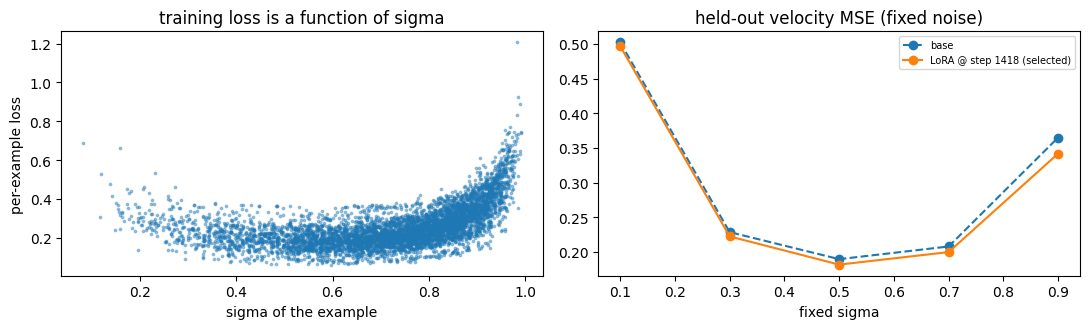

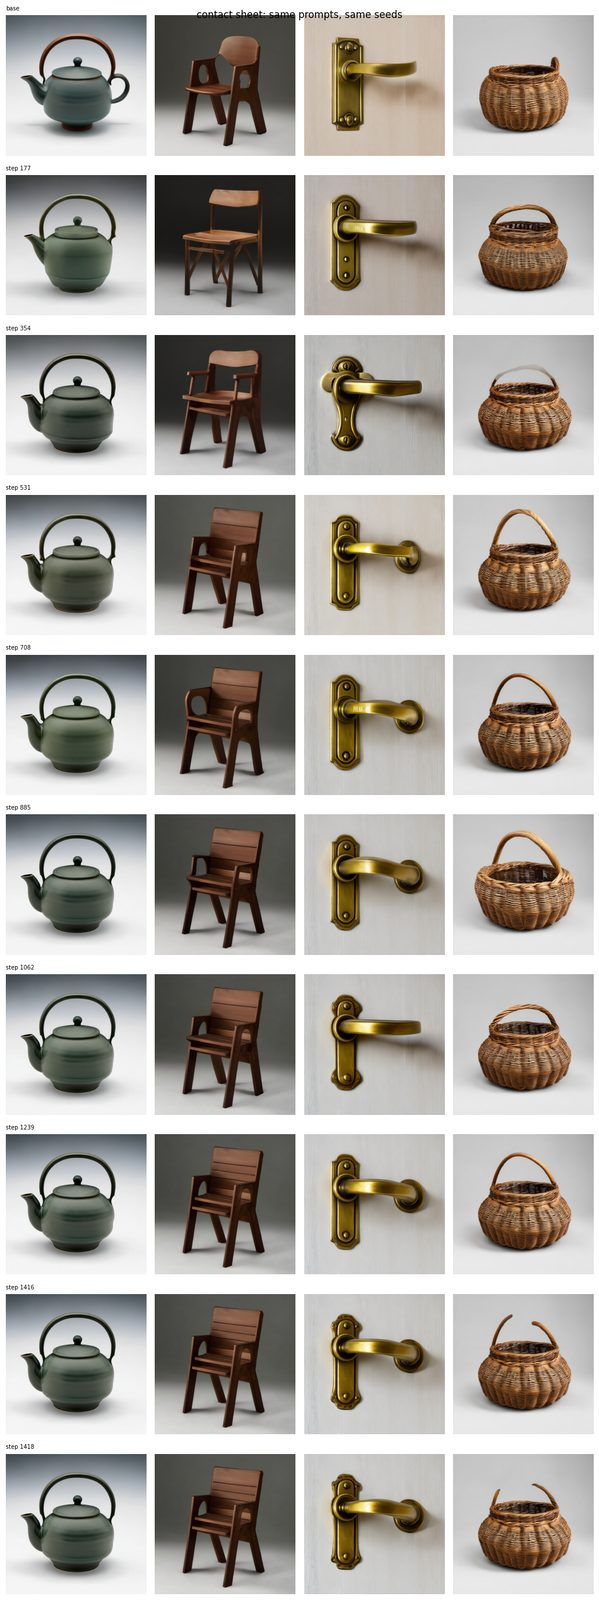

held-out velocity MSE: base 0.2986 -> 0.2885 (Δ -0.0101)
CLIP style 0.5802 -> 0.5925   adherence 0.3263 -> 0.3274
Read them together: style up with adherence roughly flat is a style LoRA; adherence
falling means the adapter is overriding prompts. A held-out velocity error that falls and then RISES
is the flow-matching overfitting signal; pick the checkpoint before the turn (notebook 55 §9).


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter([r["sigma"] for r in LOG], [r["loss"] for r in LOG], s=3, alpha=0.4)
ax[0].set_xlabel("sigma of the example"); ax[0].set_ylabel("per-example loss"); ax[0].set_title("training loss is a function of sigma")
last = EVALS[BEST_STEP]
ax[1].plot(EVAL_SIGMAS, BASE["heldout_vel_err"], "o--", label="base")
ax[1].plot(EVAL_SIGMAS, last["heldout_vel_err"], "o-", label=f"LoRA @ step {BEST_STEP} (selected)")
ax[1].set_xlabel("fixed sigma"); ax[1].set_title("held-out velocity MSE (fixed noise)"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
sheet([BASE_IMGS] + [SHEETS[s] for s in sorted(SHEETS)], ["base"] + [f"step {s}" for s in sorted(SHEETS)],
      "contact sheet: same prompts, same seeds")
d_vel = float(np.mean(last["heldout_vel_err"]) - np.mean(BASE["heldout_vel_err"]))
print(f"held-out velocity MSE: base {np.mean(BASE['heldout_vel_err']):.4f} -> {np.mean(last['heldout_vel_err']):.4f} (Δ {d_vel:+.4f})")
print(f"CLIP style {BASE['style']:.4f} -> {last['style']:.4f}   adherence {BASE['adherence']:.4f} -> {last['adherence']:.4f}")
print("""Read them together: style up with adherence roughly flat is a style LoRA; adherence
falling means the adapter is overriding prompts. A held-out velocity error that falls and then RISES
is the flow-matching overfitting signal; pick the checkpoint before the turn (notebook 55 §9).""")

## 14. Save, reload into a fresh pipeline, prove it is the same model

`StableDiffusion3Pipeline.save_lora_weights(save_directory, transformer_lora_layers=...,
transformer_lora_adapter_metadata=...)` is the SD3 signature in diffusers 0.40.0. Its
`_lora_loadable_modules` are `transformer`, `text_encoder` and `text_encoder_2`, and it prefixes
keys with `transformer.`. The metadata is what lets the loader rebuild the
`LoraConfig` with the right alpha. Without it the loader assumes `alpha = r`.

The proof: fixed-seed latents from the in-memory model, then the in-memory transformer is
deleted, a **fresh** transformer is loaded from the Hub, and the saved file is loaded into a fresh
pipeline. The adapter count and scale must match, the held-out velocity error must match, and so
must the fixed-seed latents. `joint_attention_kwargs={"scale": 0.0}` gives the base model's
latents on the same seeds. diffusers' `apply_lora_scale` wrapper handles scale 0 by resetting,
not dividing. That number tells us how large "the LoRA's effect" is, so "reload matches" has a
yardstick.

In [25]:
from safetensors import safe_open

transformer.eval()
StableDiffusion3Pipeline.save_lora_weights(
    str(OUT), transformer_lora_layers=get_peft_model_state_dict(transformer),
    transformer_lora_adapter_metadata=transformer.peft_config["default"].to_dict(), safe_serialization=True)
LORA_FILE = OUT / "pytorch_lora_weights.safetensors"
with safe_open(str(LORA_FILE), "pt") as f:
    hdr = f.metadata() or {}
    n_keys = len(list(f.keys()))
print(f"saved {LORA_FILE.name}: {LORA_FILE.stat().st_size/1e6:.1f} MB, {n_keys} tensors, header keys {list(hdr)}")
assert "lora_adapter_metadata" in hdr, "adapter metadata missing: reload would assume alpha = r"

REF_LAT = generate(gen_pipe, seed=4321)
BASE0_LAT = generate(gen_pipe, seed=4321, scale=0.0)
REF_VEL = heldout_vel_err(transformer)
del gen_pipe, opt, params
transformer.to("cpu")
del transformer
free_mem()

from peft.tuners.tuners_utils import BaseTunerLayer

fresh_tr = SD3Transformer2DModel.from_pretrained(PIPE_ID, subfolder="transformer", dtype=DTYPE).to(DEV)
fresh_pipe = make_pipe(fresh_tr)
fresh_pipe.set_progress_bar_config(disable=True)
fresh_pipe.load_lora_weights(str(OUT))
layers = [m for m in fresh_tr.modules() if isinstance(m, BaseTunerLayer)]
scal = {round(v, 6) for m in layers for v in m.scaling.values()}
print(f"reloaded: {len(layers)} LoRA layers (trained {N_LORA}), scalings {scal} (want {LORA_ALPHA / RANK})")
assert len(layers) == N_LORA, "reload attached a different number of LoRA layers"
assert scal == {round(LORA_ALPHA / RANK, 6)}, "reloaded scale != alpha/r: metadata lost"

RE_LAT = generate(fresh_pipe, seed=4321)
RE_VEL = heldout_vel_err(fresh_tr)
nrm = REF_LAT.norm().item()
rel_reload = (RE_LAT - REF_LAT).norm().item() / nrm
rel_lora = (BASE0_LAT - REF_LAT).norm().item() / nrm
d_vel_reload = max(abs(a - b) / max(abs(b), 1e-8) for a, b in zip(RE_VEL, REF_VEL))
print(f"fixed-seed latents: |reloaded - in-memory| / |in-memory| = {rel_reload:.2e}   "
      f"|base - in-memory| / |in-memory| = {rel_lora:.2e}  <- the LoRA's own effect")
print(f"held-out velocity error, max relative difference reloaded vs in-memory: {d_vel_reload:.2e}")
assert rel_reload < 1e-2, "the reloaded LoRA does not reproduce the in-memory model's fixed-seed outputs"
assert d_vel_reload < 2e-2, "the reloaded LoRA scores differently on the held-out set"
print("reload verified: fresh transformer + saved file = the trained model.")
MEAS["reload"] = {"rel_latent_diff": rel_reload, "rel_lora_effect": rel_lora, "vel_err_rel_diff": d_vel_reload,
                  "file_mb": LORA_FILE.stat().st_size / 1e6}

saved pytorch_lora_weights.safetensors: 47.8 MB, 486 tensors, header keys ['lora_adapter_metadata', 'format']


reloaded: 243 LoRA layers (trained 243), scalings {1.0} (want 1.0)
fixed-seed latents: |reloaded - in-memory| / |in-memory| = 0.00e+00   |base - in-memory| / |in-memory| = 4.60e-01  <- the LoRA's own effect
held-out velocity error, max relative difference reloaded vs in-memory: 0.00e+00
reload verified: fresh transformer + saved file = the trained model.


scale 0.0: style 0.5880  adherence 0.3258
scale 0.5: style 0.5835  adherence 0.3308
scale 1.0: style 0.5982  adherence 0.3308


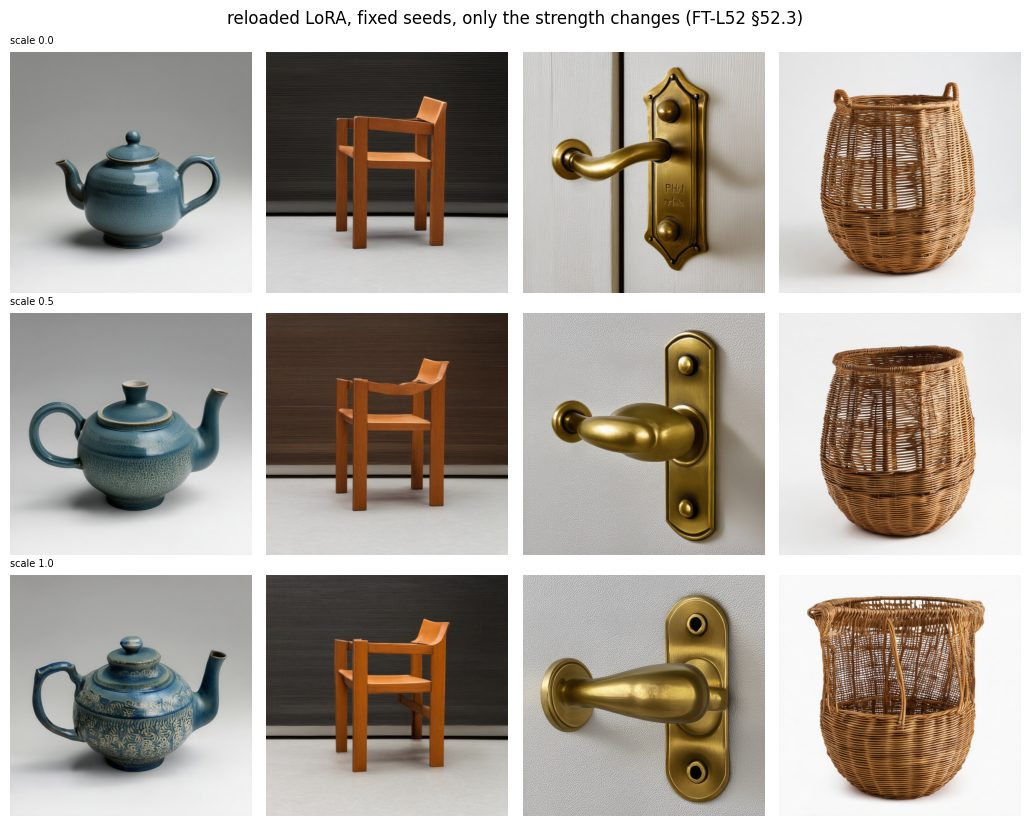

In [26]:
SCALES = [0.0, 0.5, 1.0]
SWEEP, rows = {}, []
for s in SCALES:
    ims = decode(generate(fresh_pipe, seed=4321, scale=s))
    SWEEP[s] = clip_scores(ims); rows.append(ims)
    print(f"scale {s:.1f}: style {SWEEP[s]['style']:.4f}  adherence {SWEEP[s]['adherence']:.4f}")
sheet(rows, [f"scale {s}" for s in SCALES], "reloaded LoRA, fixed seeds, only the strength changes")
MEAS["strength_sweep"] = SWEEP

## 15. Guidance-distilled models, and the road to Qwen-Image

**Not every flow-matching model is trained or sampled the same way**. Here is what diffusers 0.40.0's code and
the configs we could read say:

| model | CFG at inference | what it means for a LoRA |
|---|---|---|
| SD3 / SD3.5 (this notebook) | **real CFG**: two passes, `guidance_scale` in `StableDiffusion3Pipeline` | train on the plain conditional loss; sample with the usual CFG |
| FLUX.1-dev | **guidance-distilled**: `FluxTransformer2DModel(guidance_embeds=True)` takes a `guidance` input. `FluxPipeline` embeds `guidance_scale` into it when `transformer.config.guidance_embeds` is set; its docstring says such models "approximate true classifier-free guidance". One pass per step | during training the transformer still needs a `guidance` value, and what you feed it is part of the recipe. Real CFG (`true_cfg_scale`) is a separate knob |
| FLUX.1-schnell | **step-distilled**: the `FluxPipeline` docstring example runs it with `num_inference_steps=4, guidance_scale=0.0` | the ordinary flow-matching loss trains towards a *many-step* model, so a plain LoRA can erode the few-step behaviour. Treat that as a risk to measure at the step count you deploy, not a solved problem |
| Qwen-Image | **real CFG** (`true_cfg_scale`, default 4.0 in `QwenImagePipeline.__call__`); its transformer config has `guidance_embeds: false` | like SD3: plain loss, CFG at sampling |

**Mapping this notebook onto Qwen-Image** (the desi-max base):

* **Same objective.** A `FlowMatchEulerDiscreteScheduler` with **dynamic** shifting (§5.4), so
  training sigmas are unshifted and the resolution-dependent shift is applied at inference.
  The training loop above carries over with the target `noise - x0`.
* **Same save API shape.** `QwenImagePipeline.save_lora_weights(save_directory,
  transformer_lora_layers=..., transformer_lora_adapter_metadata=...)`. It has no text-encoder
  slots at all.
* **Different everything else.** A 20 B, 60-layer transformer; a Qwen2.5-VL text encoder instead
  of CLIP + T5; a different VAE with 2×2-packed latents (`in_channels: 64` = 16 × 2 × 2). None of
  it fits a T4 (§6). On a 48 GB card, the notebook 55 workflow plus this section's objective is
  the recipe.

In [27]:
from diffusers import QwenImagePipeline, FluxTransformer2DModel, FluxPipeline

QT = json.load(open(hf_hub_download(QWEN_ID, "transformer/config.json")))
print(f"{QWEN_ID} transformer: layers {QT['num_layers']}  heads {QT['num_attention_heads']}x{QT['attention_head_dim']}  "
      f"in_channels {QT['in_channels']}  guidance_embeds {QT['guidance_embeds']}")
print("QwenImagePipeline.save_lora_weights", inspect.signature(QwenImagePipeline.save_lora_weights))
print("FluxTransformer2DModel guidance_embeds default:",
      inspect.signature(FluxTransformer2DModel.__init__).parameters["guidance_embeds"].default)
print("FluxPipeline.__call__ has true_cfg_scale:", "true_cfg_scale" in inspect.signature(FluxPipeline.__call__).parameters)

config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

Qwen/Qwen-Image-2512 transformer: layers 60  heads 24x128  in_channels 64  guidance_embeds False
QwenImagePipeline.save_lora_weights (save_directory: str | os.PathLike, transformer_lora_layers: dict[str, torch.nn.modules.module.Module | torch.Tensor] = None, is_main_process: bool = True, weight_name: str = None, save_function: Callable = None, safe_serialization: bool = True, transformer_lora_adapter_metadata: dict | None = None)
FluxTransformer2DModel guidance_embeds default: False
FluxPipeline.__call__ has true_cfg_scale: True


## 16. The card

In [28]:
def sh(c):
    try:
        return subprocess.check_output(c, shell=True, text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return None


import diffusers, transformers, peft

CARD = {
    "context": "flow-matching objective (toy) + LoRA on an SD3-family MMDiT with cached T5/CLIP embeddings",
    "quick_mode": QUICK, "base_model": PIPE_ID, "base_model_licence": HUB.get(PIPE_ID, {}).get("license_name")
    or HUB.get(PIPE_ID, {}).get("license"), "dataset": (f"local folder {STYLE_DIR}" if STYLE_DIR else DATA_ID), "dataset_licence": dlic,
    "credit": "" if STYLE_DIR else "Cooper Hewitt, Smithsonian Design Museum", "trigger": TRIGGER,
    "record_ids_train": [r["record_id"] for r in TRAIN],
    "objective": {"target": "noise - x0", "path": "x_t = (1-s) x0 + s noise", "timestep_density": WEIGHTING,
                  "loss_weighting": LOSS_WEIGHTING, "scheduler_config": dict(sched_infer.config)},
    "lora": {"r": RANK, "alpha": LORA_ALPHA, "targets": LORA_TARGETS, "layers": N_LORA, "trainable": n_tr},
    "schedule": {"steps": MAX_STEPS, "batch": BATCH, "grad_acc": GRAD_ACC, "lr": LR, "resolution": RES,
                 "image_tokens": N_IMG_TOK, "text_tokens": N_TXT_TOK, "max_sequence_length": MAX_SEQ},
    "precision": {"base": str(DTYPE), "lora_params": "float32", "vae": "float32", "grad_scaler": scaler.is_enabled()},
    "measured": MEAS, "lora_file": str(LORA_FILE),
    "git_sha": sh("git rev-parse HEAD"), "git_dirty": bool(sh("git status --porcelain")),
    "versions": {"torch": torch.__version__, "diffusers": diffusers.__version__,
                 "transformers": transformers.__version__, "peft": peft.__version__},
}
json.dump(CARD, open(OUT / "CARD.json", "w"), indent=2, default=str)
print(json.dumps(CARD, indent=2, default=str)[:2500])

{
  "context": "flow-matching objective (toy) + LoRA on an SD3-family MMDiT with cached T5/CLIP embeddings",
  "quick_mode": false,
  "base_model": "stabilityai/stable-diffusion-3.5-medium",
  "base_model_licence": "stabilityai-ai-community",
  "dataset": "local folder /content/desi_repo/finetune/notebooks/data/matchbox_india",
  "dataset_licence": "unspecified",
  "credit": "",
  "trigger": "phlmx",
  "record_ids_train": [
    "mb_110.jpg",
    "mb_043.jpg",
    "mb_003.jpg",
    "mb_156.jpg",
    "mb_114.jpg",
    "mb_013.jpg",
    "mb_080.jpg",
    "mb_014.jpg",
    "mb_091.jpg",
    "mb_070.jpg",
    "mb_004.jpg",
    "mb_185.jpg",
    "mb_031.jpg",
    "mb_165.jpg",
    "mb_169.jpg",
    "mb_016.jpg",
    "mb_159.jpg",
    "mb_037.jpg",
    "mb_134.jpg",
    "mb_045.jpg",
    "mb_006.jpg",
    "mb_054.jpg",
    "mb_085.jpg",
    "mb_081.jpg",
    "mb_065.jpg",
    "mb_074.jpg",
    "mb_038.jpg",
    "mb_126.jpg",
    "mb_119.jpg",
    "mb_079.jpg",
    "mb_160.jpg",
    "mb_067.jp

## 17. Generate images with the trained LoRA

Generation runs in a fresh **full** pipeline with all three text encoders, so any prompt works.
The next cell uses the LoRA this run saved in §14; if there is none, it downloads the published
one from [spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator](https://huggingface.co/spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator) (`sd3.5-medium/`). Every image and grid is saved to
`out/<FT_RUN_NAME>/generations`.

The settings of the published images: LoRA scale 0.9, 28 steps, CFG 5.0, 768 x 1152 (portrait) or
1152 x 768 (landscape), seeds 1 to 4, and the same negative prompt as notebook 55.

Prompts follow the hand-written training captions: `phlmx, a matchbox label, <what is shown>,
<background colour>, headline '<1 or 2 words>'`. Some prompts below say "a matchbox" instead of
"a matchbox label"; both work.


In [ ]:
import os, re, json, random
from pathlib import Path
import torch
from huggingface_hub import hf_hub_download
from diffusers import StableDiffusion3Pipeline
from diffusers.utils import make_image_grid
from IPython.display import display

HF_MODEL = "spearb0lt/Indian-Matchbox-Art-Style-Text-to-Image-Generator"     # the published weights
_run = Path("out") / os.environ.get("FT_RUN_NAME", "69_matchbox_india")
if (_run / "pytorch_lora_weights.safetensors").exists():          # this run's LoRA (§14)
    LORA_DIR = str(_run)
else:                                                             # nothing trained here: the published LoRA
    LORA_DIR = os.path.dirname(hf_hub_download(HF_MODEL, "sd3.5-medium/pytorch_lora_weights.safetensors"))
    hf_hub_download(HF_MODEL, "sd3.5-medium/CARD.json")
card = json.load(open(f"{LORA_DIR}/CARD.json"))
print("LoRA", LORA_DIR, "| trigger", card["trigger"], "| res", card["schedule"]["resolution"],
      "| best step", card["measured"]["train"].get("best_step"))
_dt = torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float16
pipe = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-medium", torch_dtype=_dt).to("cuda")
pipe.load_lora_weights(LORA_DIR, weight_name="pytorch_lora_weights.safetensors")
pipe.set_progress_bar_config(disable=True)
SAVE = str(_run / "generations"); os.makedirs(SAVE, exist_ok=True)
NEG = "photograph, photorealistic, 3d render, blurry, low quality, watermark"


def gen(prompt, seeds=(1, 2, 3, 4), scale=0.9, w=768, h=1152, steps=28, cfg=5.0):
    """A row of images, one per seed; saved as one grid."""
    imgs = [pipe(prompt, negative_prompt=NEG, width=w, height=h, num_inference_steps=steps, guidance_scale=cfg,
                 joint_attention_kwargs={"scale": scale}, generator=torch.Generator("cuda").manual_seed(s)).images[0]
            for s in seeds]
    g = make_image_grid(imgs, rows=1, cols=len(imgs))
    g.save(f"{SAVE}/{re.sub(r'[^a-z0-9]+', '_', prompt.lower())[:70]}_s{scale}.png")
    return g


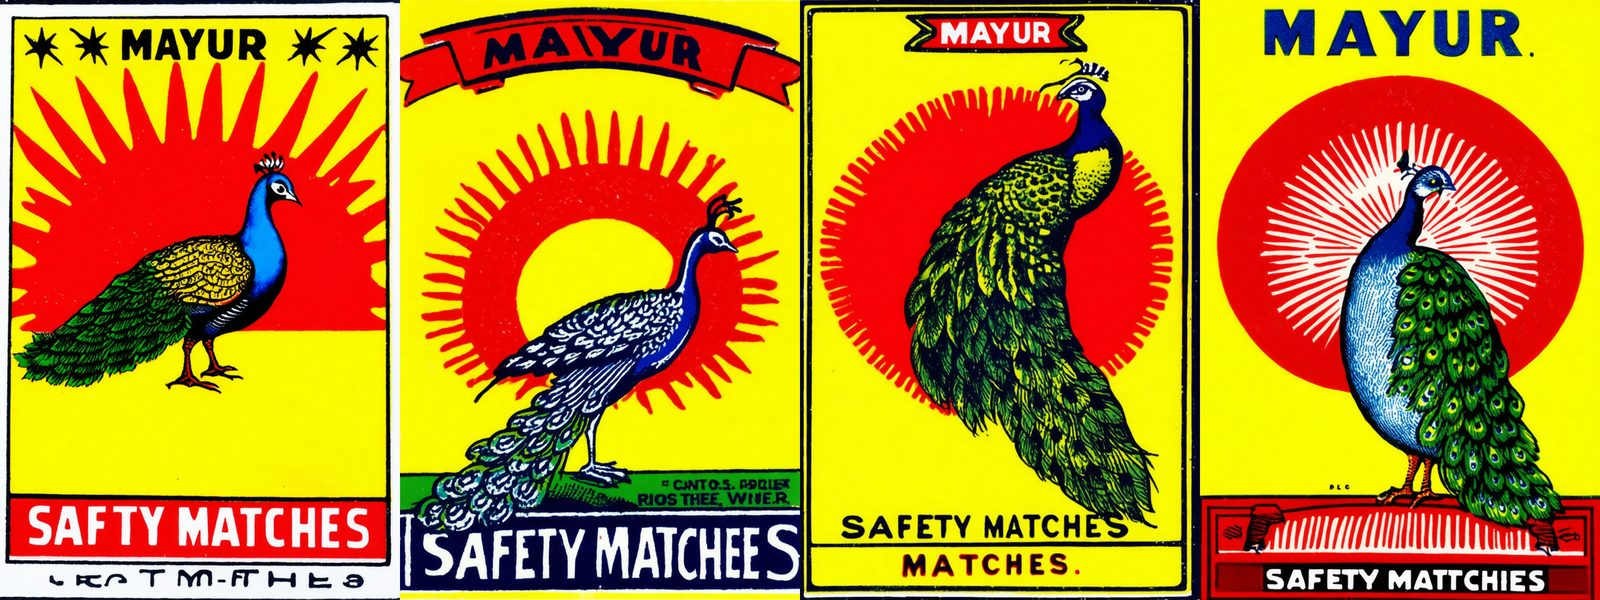

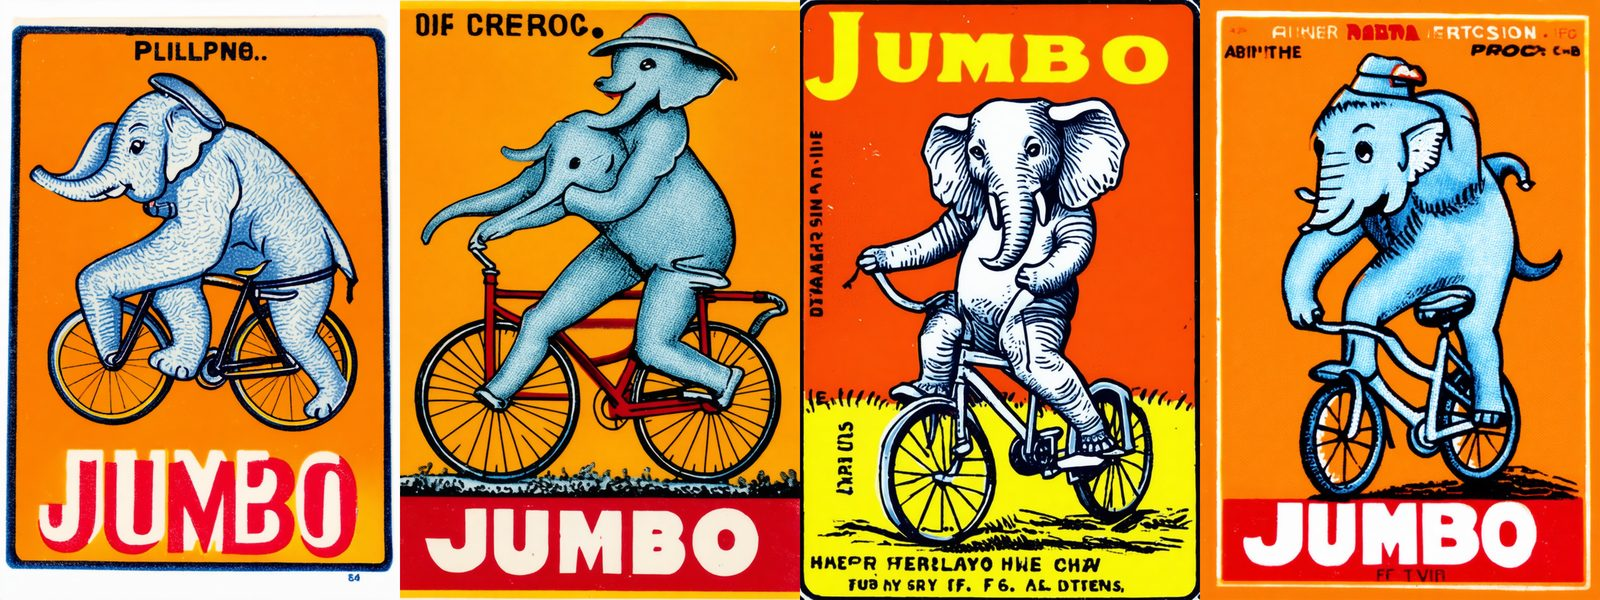

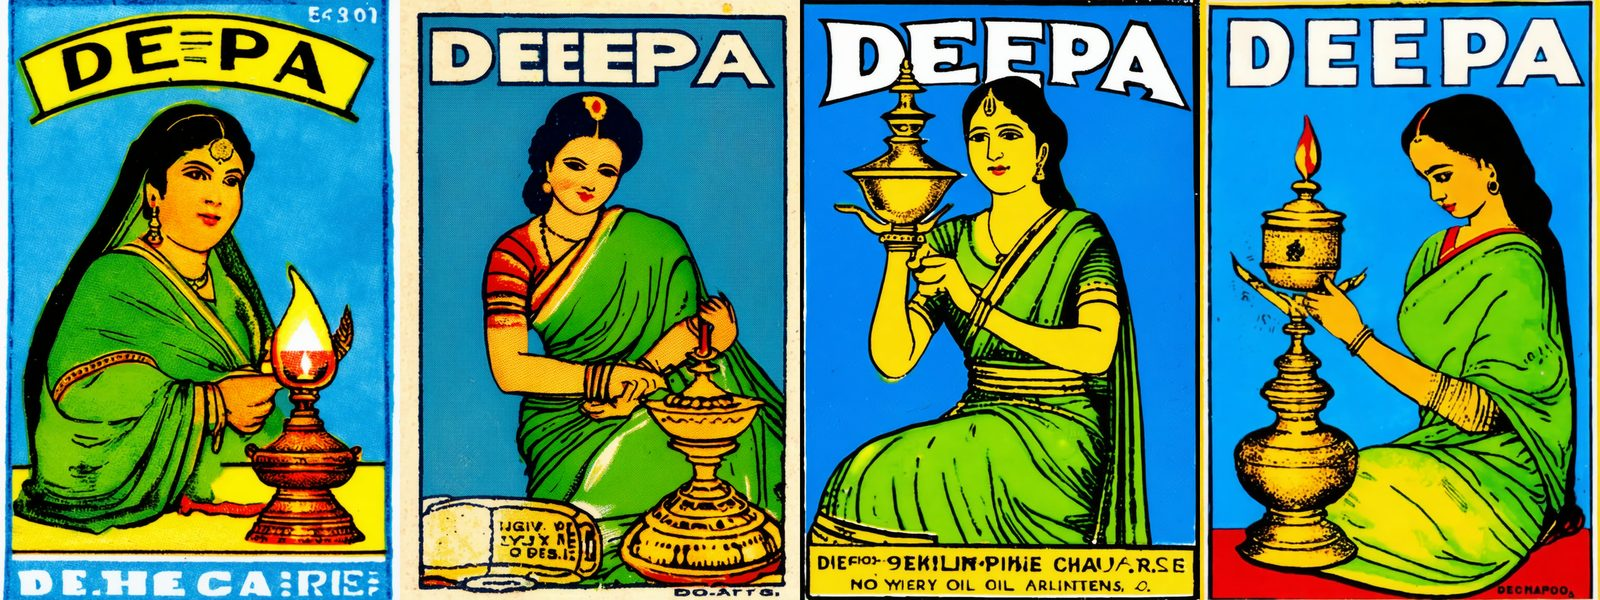

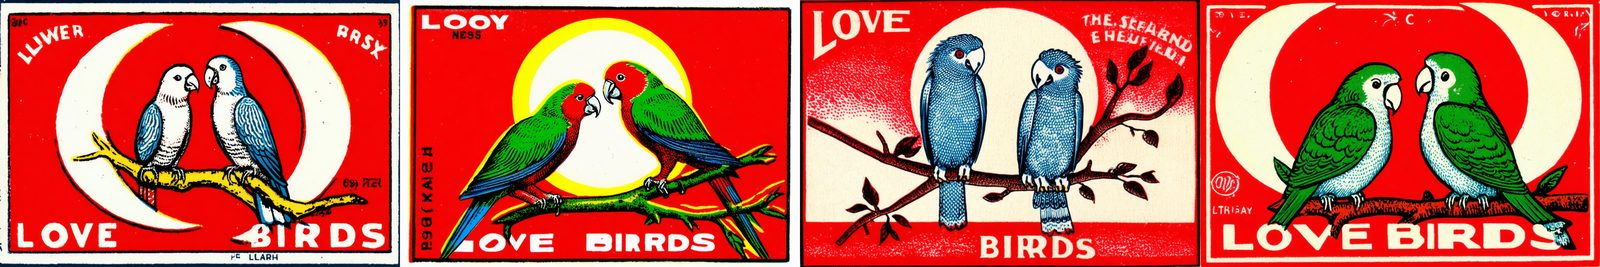

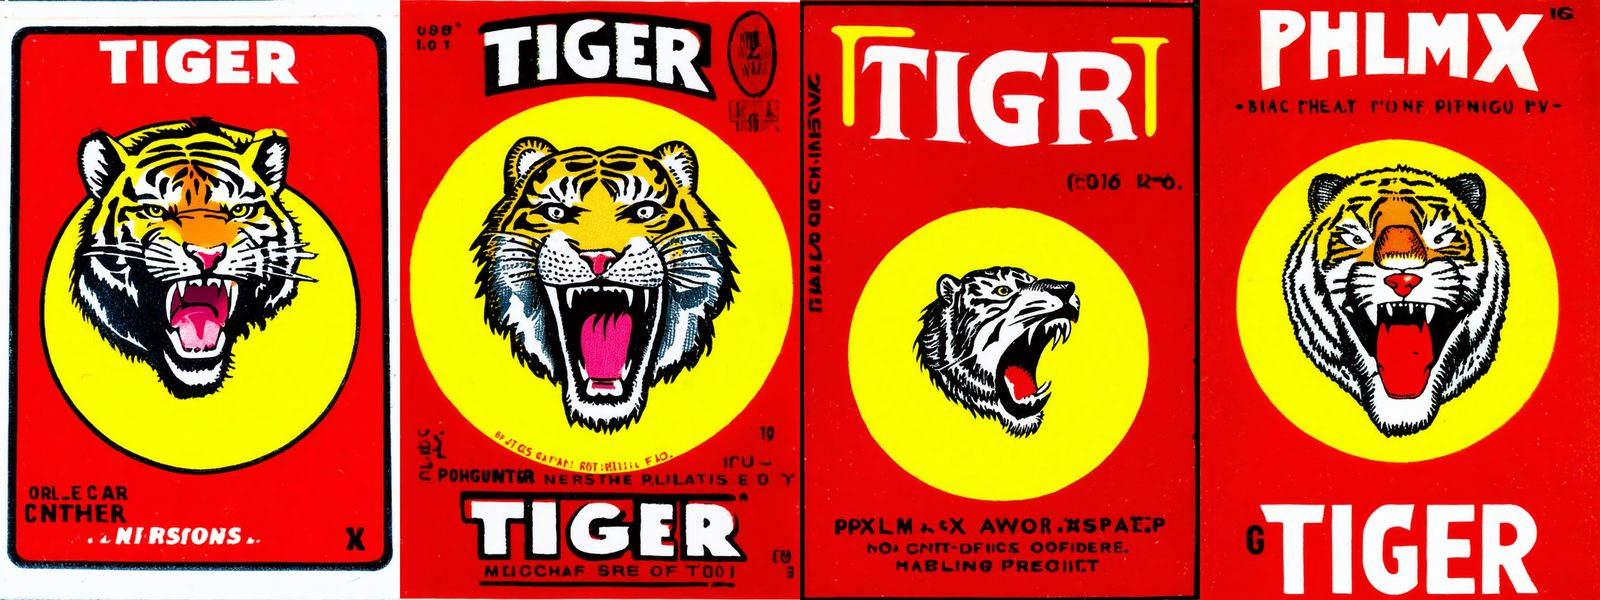

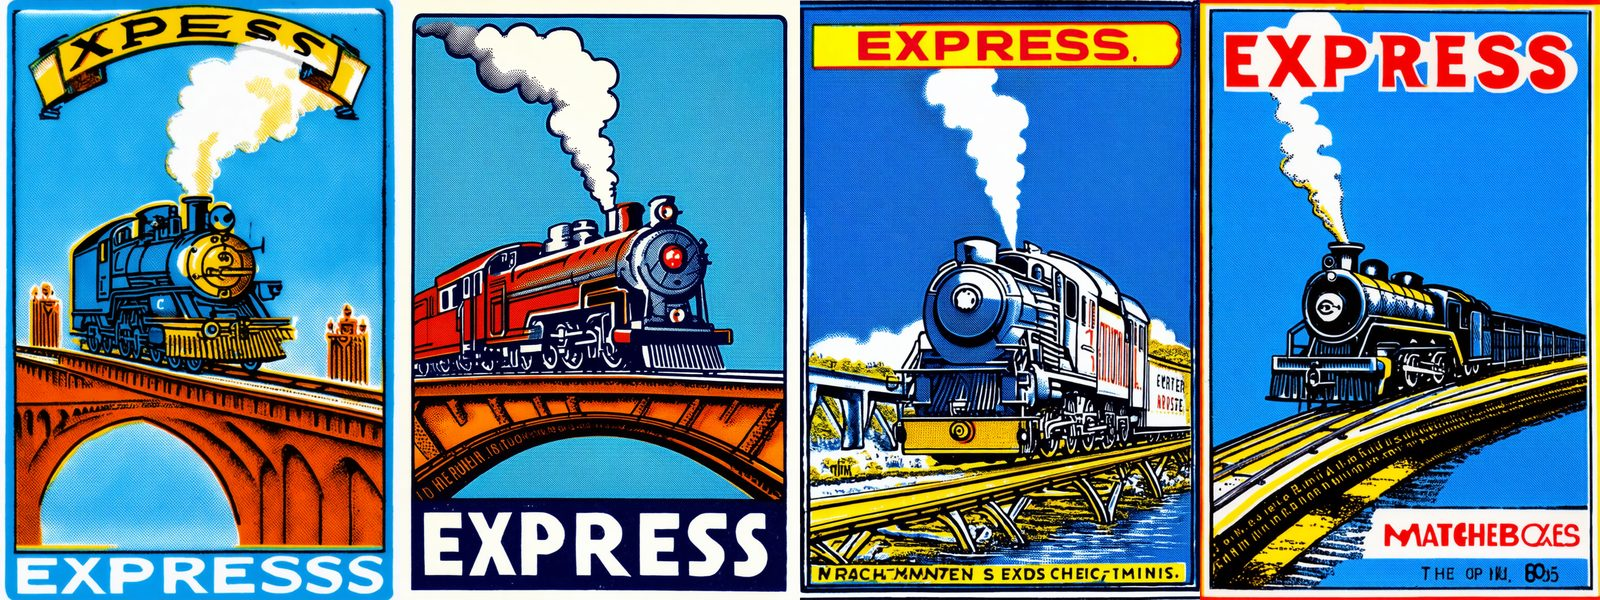

In [2]:
display(gen("phlmx, a matchbox label, a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR', text 'Safety Matches'"))
display(gen("phlmx, a matchbox label, a cartoon elephant riding a bicycle, orange background, headline 'JUMBO'"))
display(gen("phlmx, a matchbox label, a woman in a green sari lighting a brass oil lamp, blue background, headline 'DEEPA'"))
display(gen("phlmx, a matchbox label, two parrots on a branch under a crescent moon, red background, headline 'LOVE BIRDS'", w=1152, h=768))
display(gen("phlmx, a matchbox label, a roaring tiger's head inside a yellow circle, red background, headline 'TIGER'"))
display(gen("phlmx, a matchbox label, a steam locomotive crossing a bridge, blue background, headline 'EXPRESS'"))


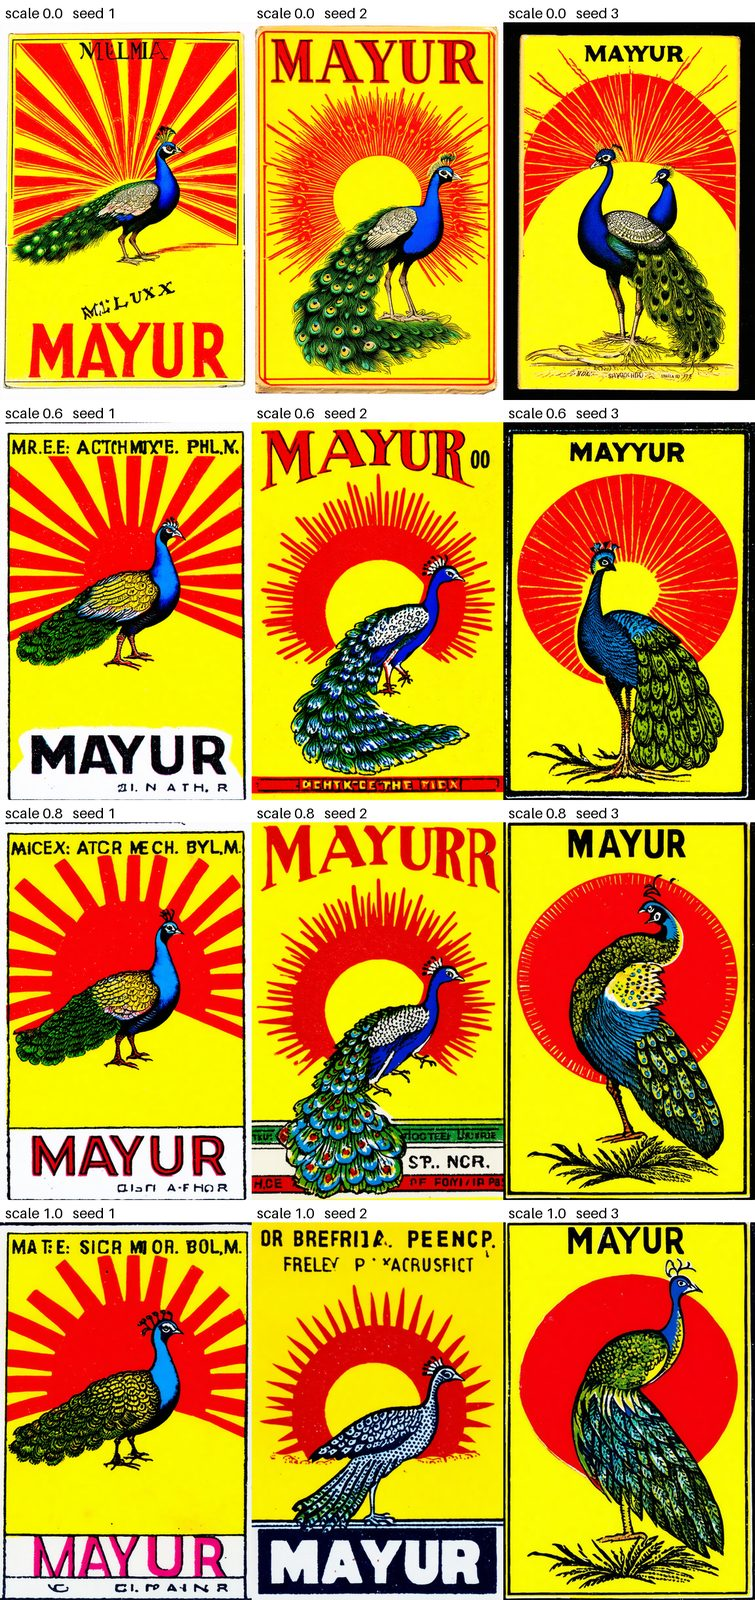

In [9]:

import torch
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

def _font(size=22):
    try:
        return ImageFont.load_default(size=size)
    except TypeError:                      # older Pillow: fixed small font
        return ImageFont.load_default()

def label_grid(rows, scales, seeds, w, h, thumb=384):
    """rows[i][j] = image for scales[i], seeds[j]; returns one labelled grid."""
    tw, th, pad = thumb, round(thumb * h / w), 34
    grid = Image.new("RGB", (len(seeds) * tw, len(scales) * (th + pad)), "white")
    d, f = ImageDraw.Draw(grid), _font()
    for r, (sc, imgs) in enumerate(zip(scales, rows)):
        for c, (s, im) in enumerate(zip(seeds, imgs)):
            y = r * (th + pad)
            grid.paste(im.resize((tw, th), Image.LANCZOS), (c * tw, y + pad))
            d.text((c * tw + 8, y + 6), f"scale {sc}   seed {s}", fill="black", font=f)
    return grid

def strength_grid_sd3(prompt, scales=(0.0, 0.6, 0.8, 1.0), seeds=(1, 2, 3), w=768, h=1152, steps=28, cfg=5.0):
    rows = [[pipe(prompt, negative_prompt=NEG, width=w, height=h, num_inference_steps=steps, guidance_scale=cfg,
                  joint_attention_kwargs={"scale": sc}, generator=torch.Generator("cuda").manual_seed(s)).images[0]
             for s in seeds] for sc in scales]
    grid = label_grid(rows, scales, seeds, w, h)
    grid.save(f"{SAVE}/strength_{re.sub(r'[^a-z0-9]+', '_', prompt.lower())[:60]}.png")
    return grid

display(strength_grid_sd3("phlmx, a matchbox label, a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR'"))


seed 887321415  scale 0.8  768x1152  steps 28  cfg 5.0  -> phlmx_a_matchbox_label_a_peacock_with_a_fanned_tail_in_front_s0.8_seed887321415_768x1152.png


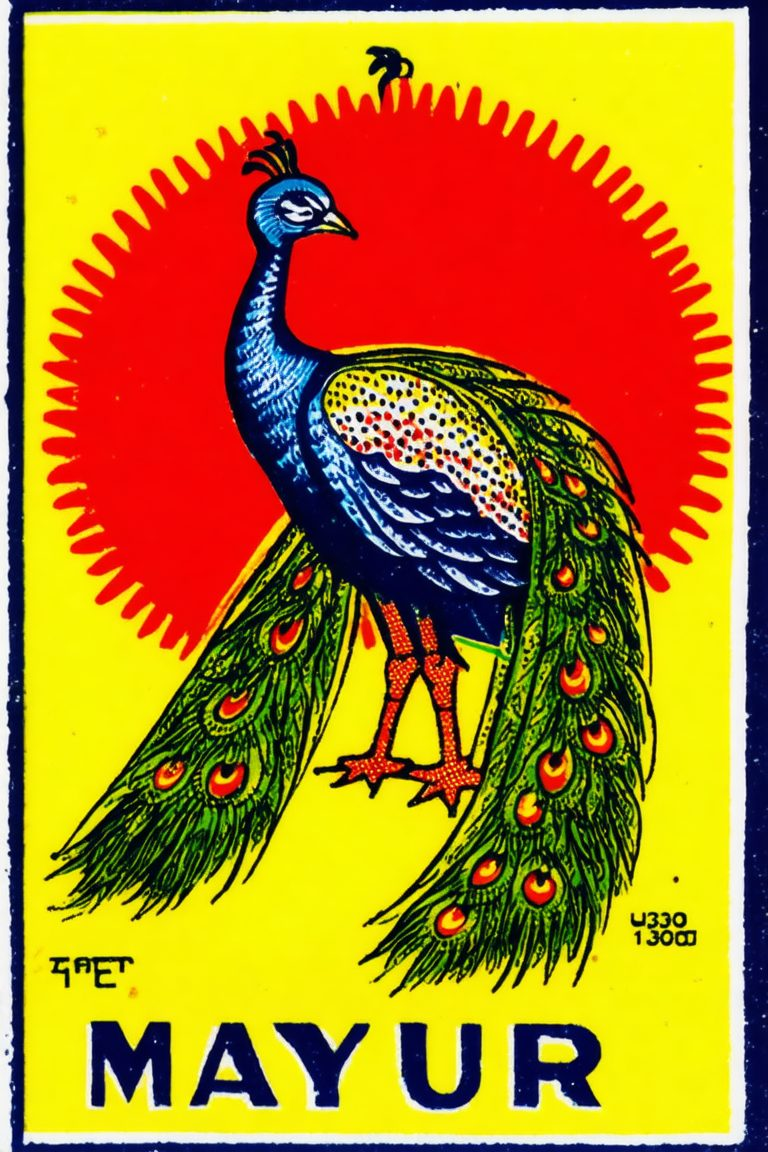

seed 42  scale 0.9  1152x768  steps 28  cfg 5.0  -> phlmx_a_matchbox_label_two_blue_elephants_facing_each_other__s0.9_seed42_1152x768.png


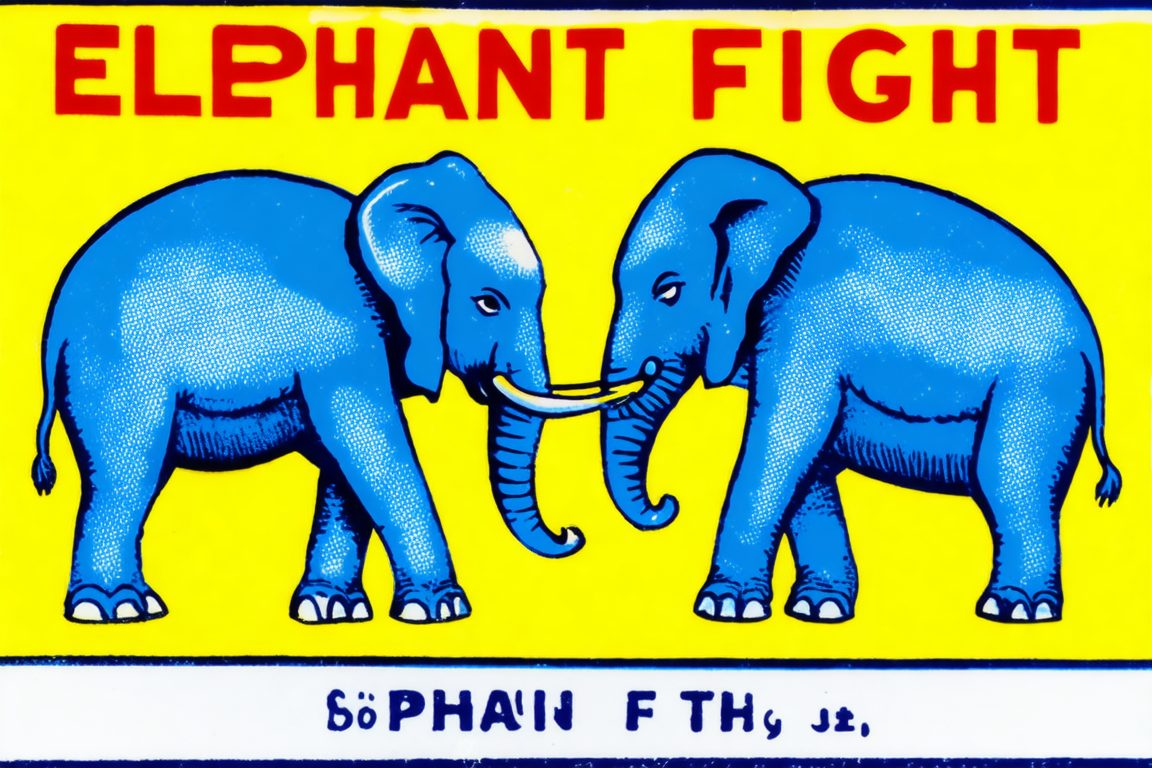

In [11]:
import re, random, torch
from IPython.display import display

def gen_one_sd3(prompt, scale=0.8, seed=None, w=768, h=1152, steps=28, cfg=5.0, neg=None):
    seed = random.randint(0, 2**31 - 1) if seed is None else seed
    img = pipe(prompt, negative_prompt=NEG if neg is None else neg, width=w, height=h,
               num_inference_steps=steps, guidance_scale=cfg, joint_attention_kwargs={"scale": scale},
               generator=torch.Generator("cuda").manual_seed(seed)).images[0]
    name = f"{re.sub(r'[^a-z0-9]+', '_', prompt.lower())[:60]}_s{scale}_seed{seed}_{w}x{h}.png"
    img.save(f"{SAVE}/{name}")
    print(f"seed {seed}  scale {scale}  {w}x{h}  steps {steps}  cfg {cfg}  -> {name}")
    return img

display(gen_one_sd3("phlmx, a matchbox label, a peacock with a fanned tail in front of a red sunburst, yellow background, headline 'MAYUR'"))
display(gen_one_sd3("phlmx, a matchbox label, two blue elephants facing each other, yellow background, headline 'ELEPHANT FIGHT'",
                    scale=0.9, seed=42, w=1152, h=768))


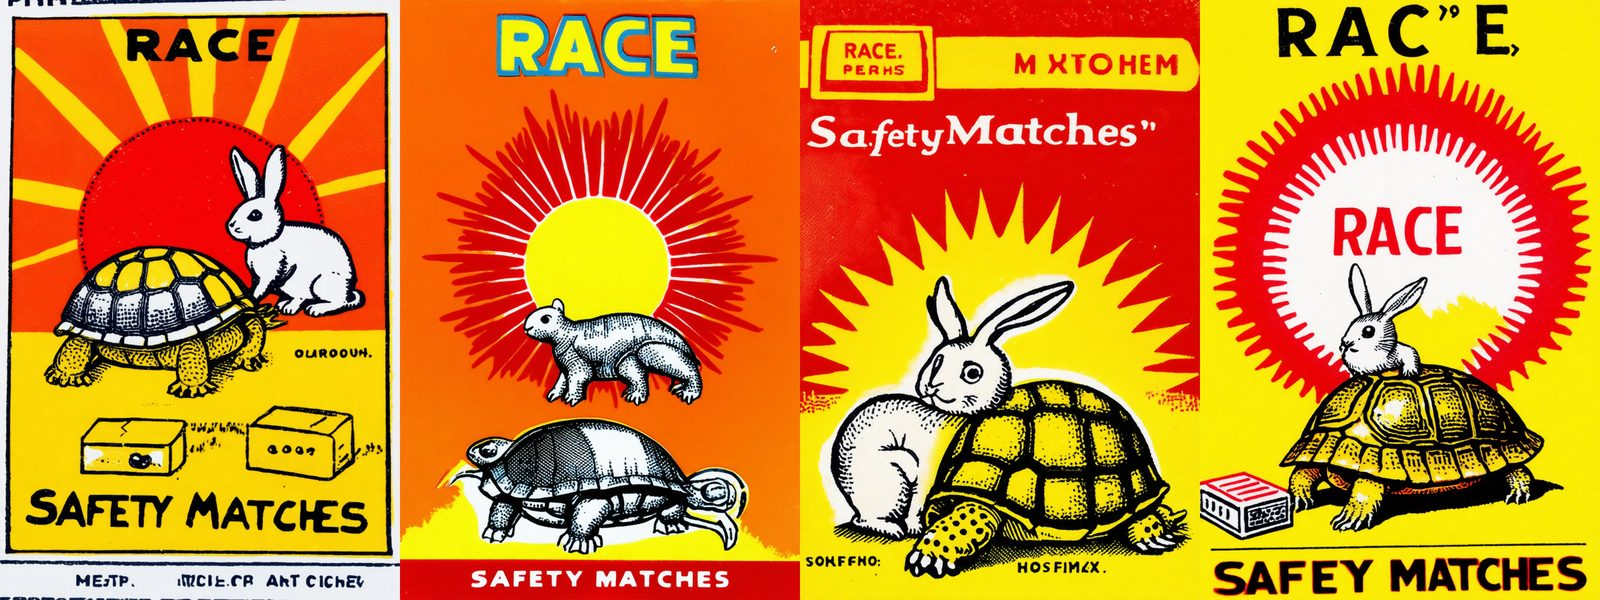

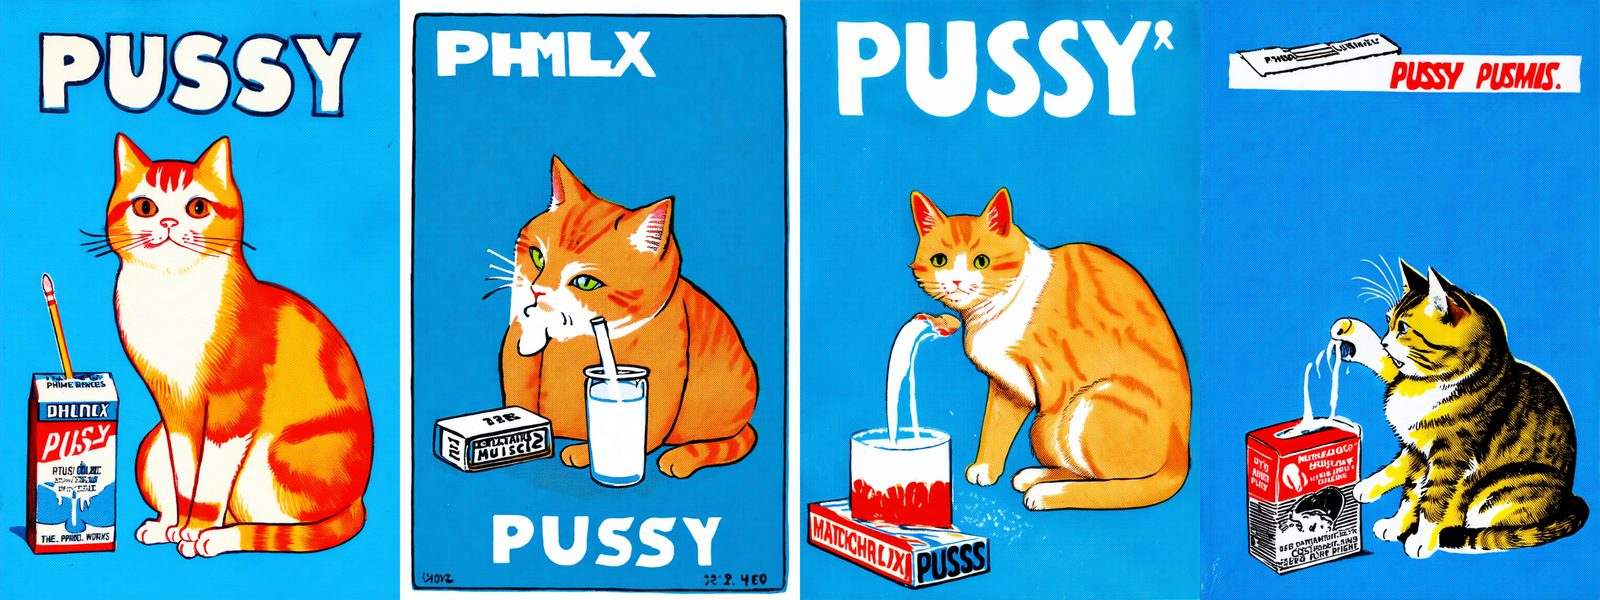

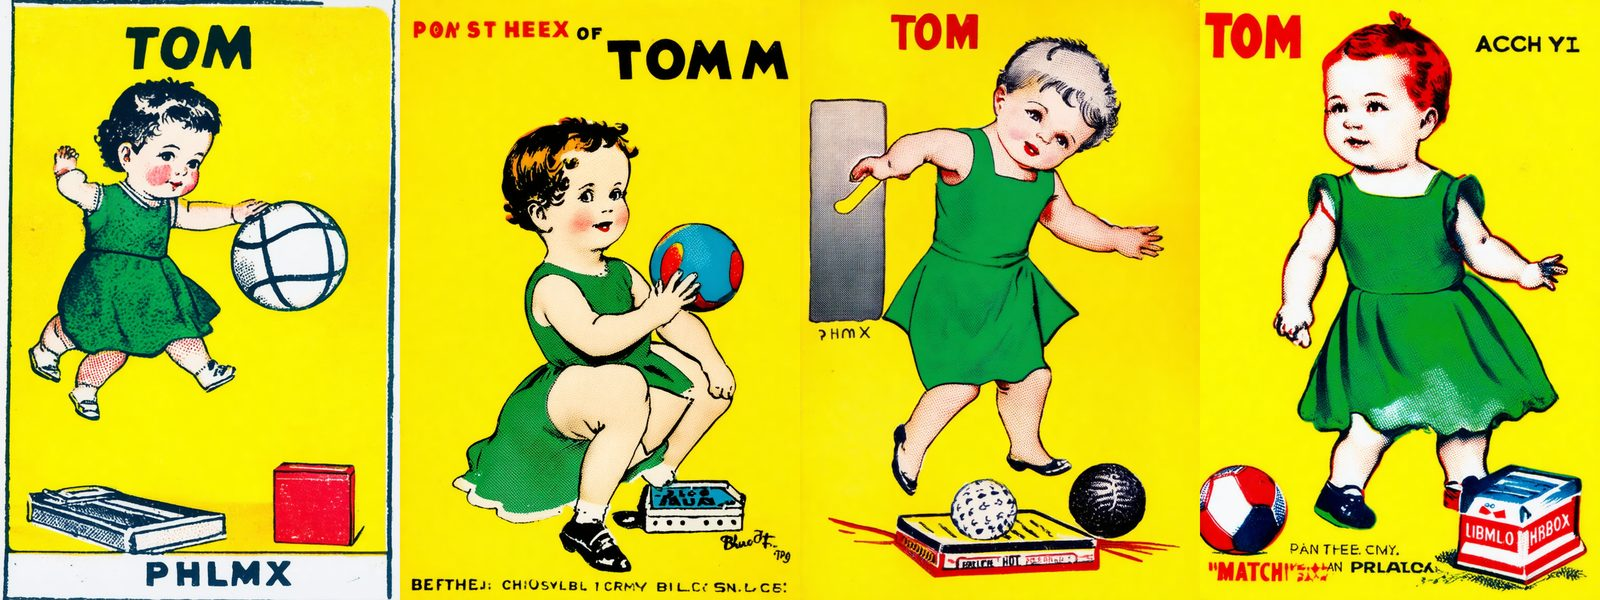

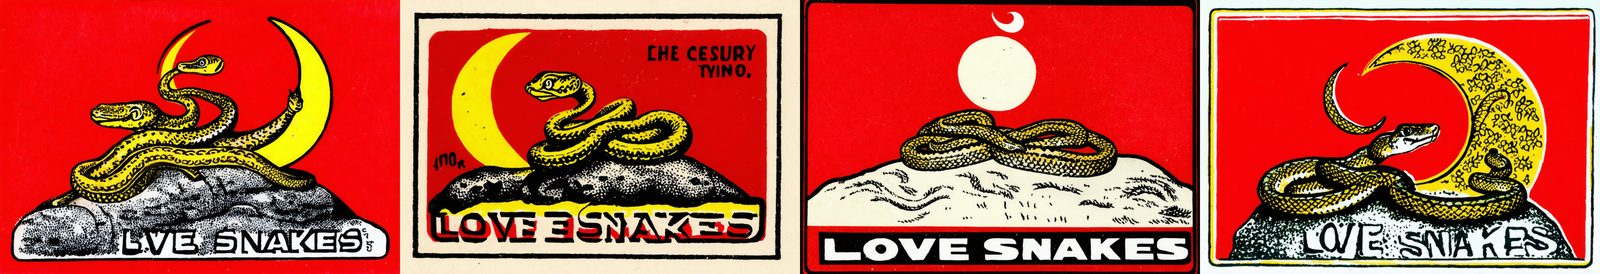

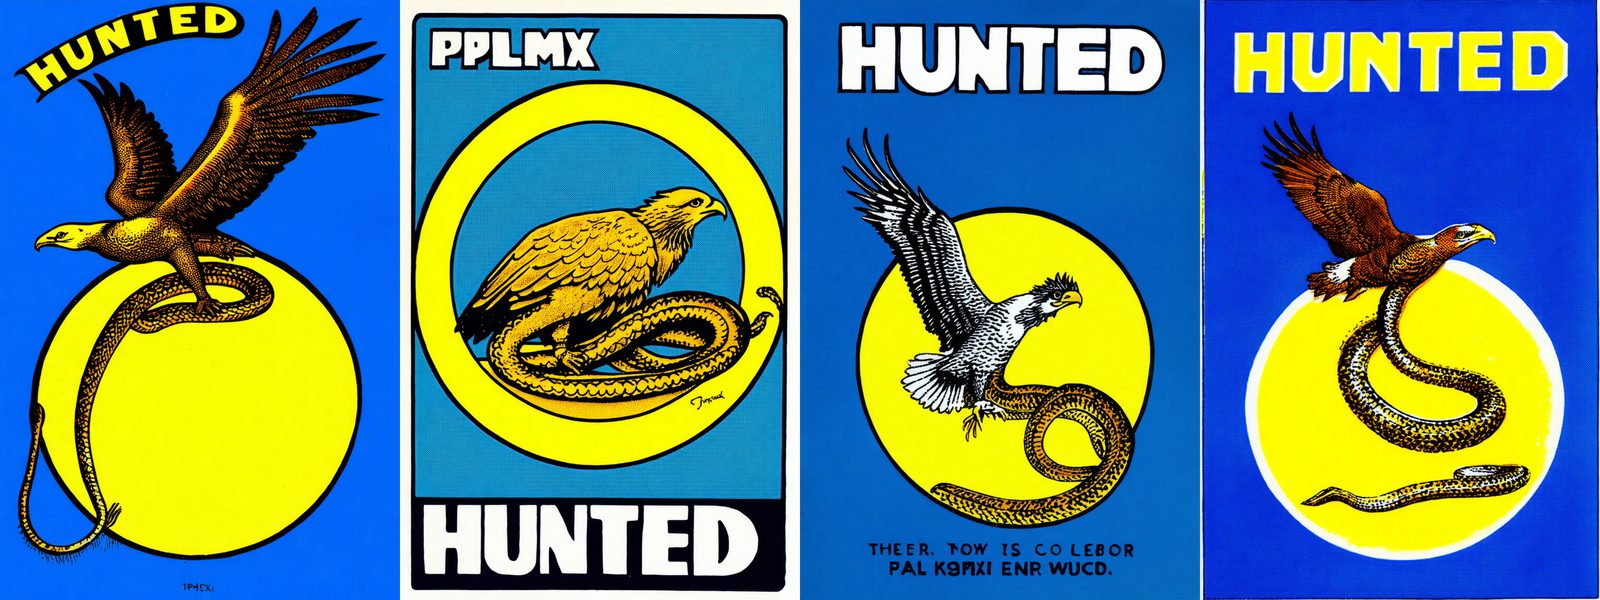

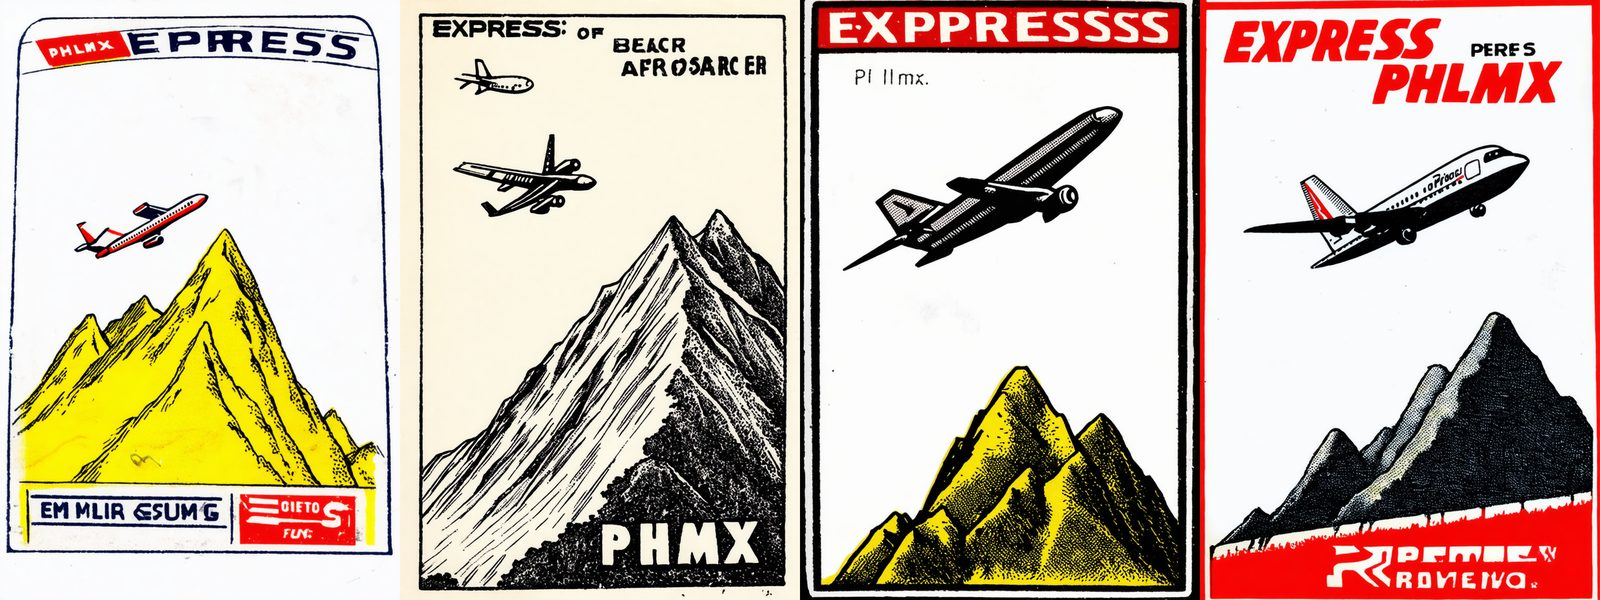

In [13]:
display(gen("phlmx, a matchbox, a tortoise with a rabbit in front of a red sunburst, orange background, headline 'RACE', text 'Safety Matches'"))
display(gen("phlmx, a matchbox, a cat drinking milk, blue background, headline 'PUSSY'"))
display(gen("phlmx, a matchbox, a baby in a green dress playing with ball, yellow background, headline 'TOM'"))
display(gen("phlmx, a matchbox, two snakes on a rock under a crescent moon, red background, headline 'LOVE SNAKES'", w=1216, h=832))
display(gen("phlmx, a matchbox, an eagle hunting a snake inside a yellow circle, blue background, headline 'HUNTED'"))
display(gen("phlmx, a matchbox, an aeroplane crossing a mountain, white background, headline 'EXPRESS'"))


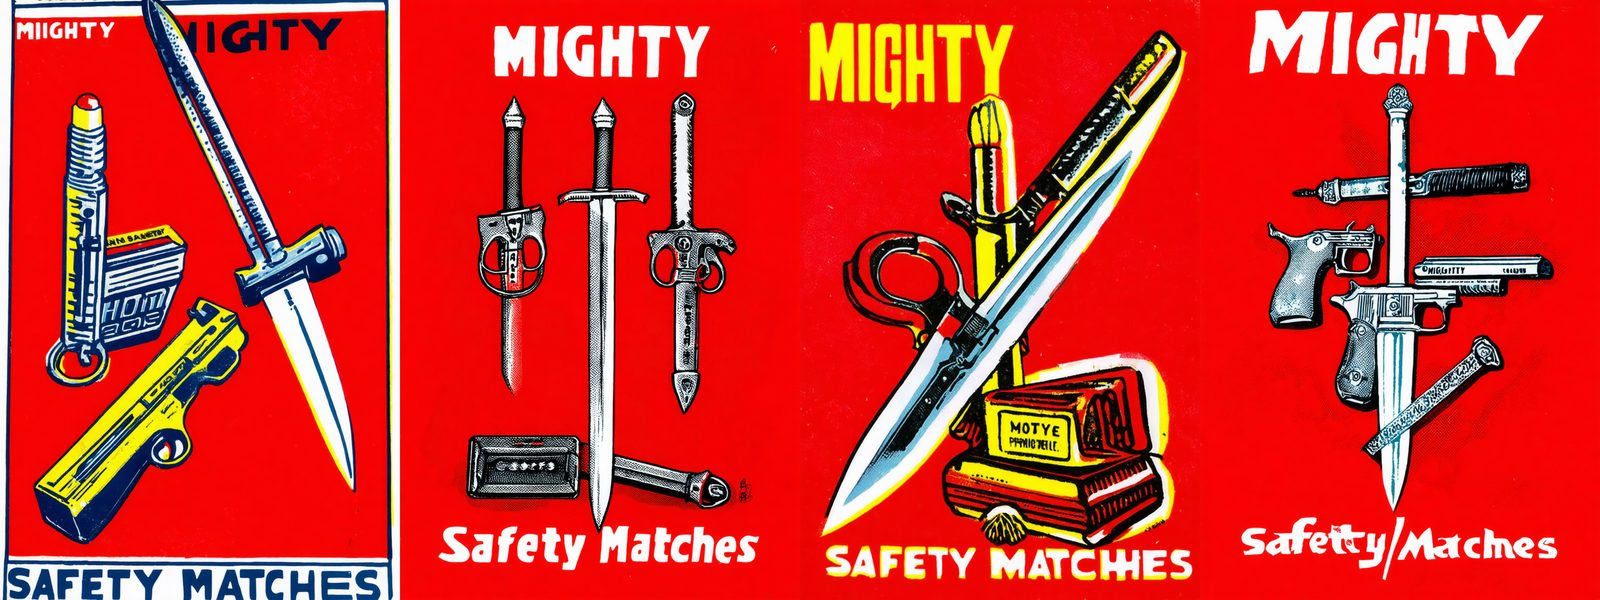

In [14]:
display(gen("phlmx, a matchbox, a gun and a sword in the backdrop of a pen, red background, headline 'MIGHTY', text 'Safety Matches'"))


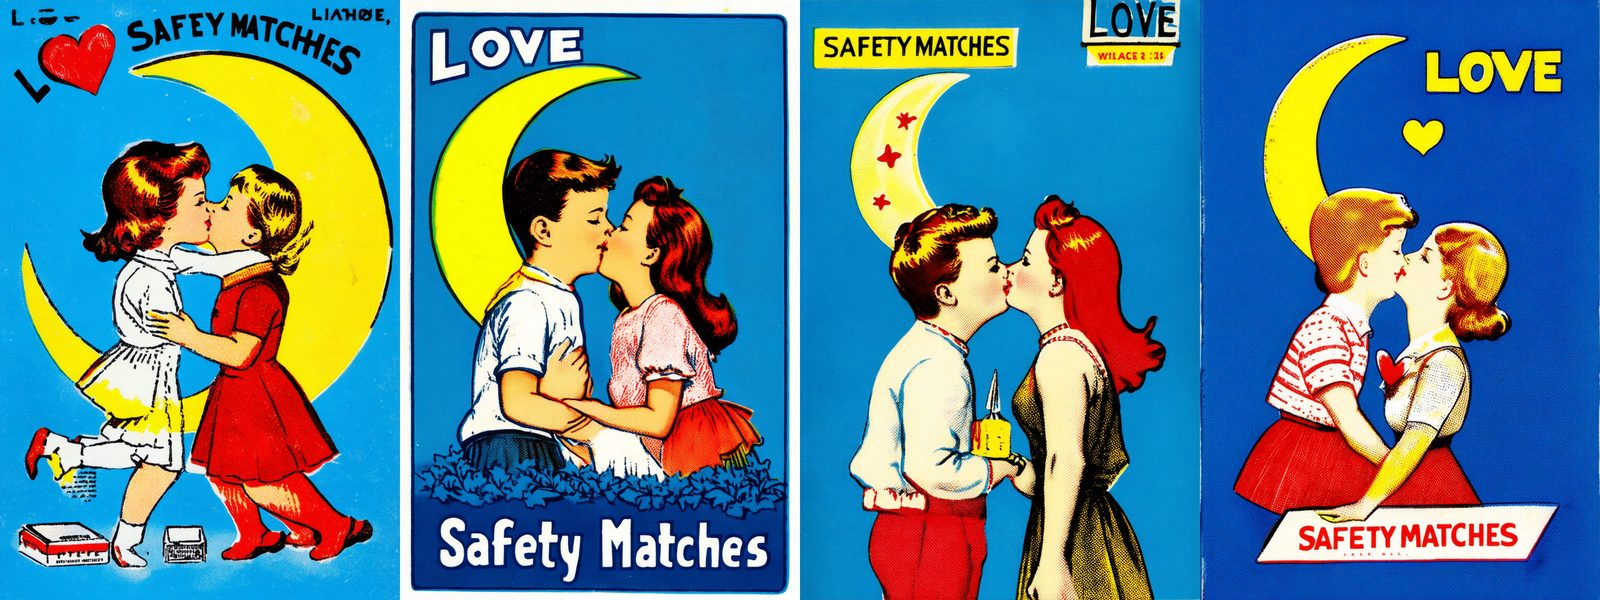

In [15]:
display(gen("phlmx, a matchbox, a boy and a girl kissing in under a crescent moon, blue background, headline 'LOVE', text 'Safety Matches'"))


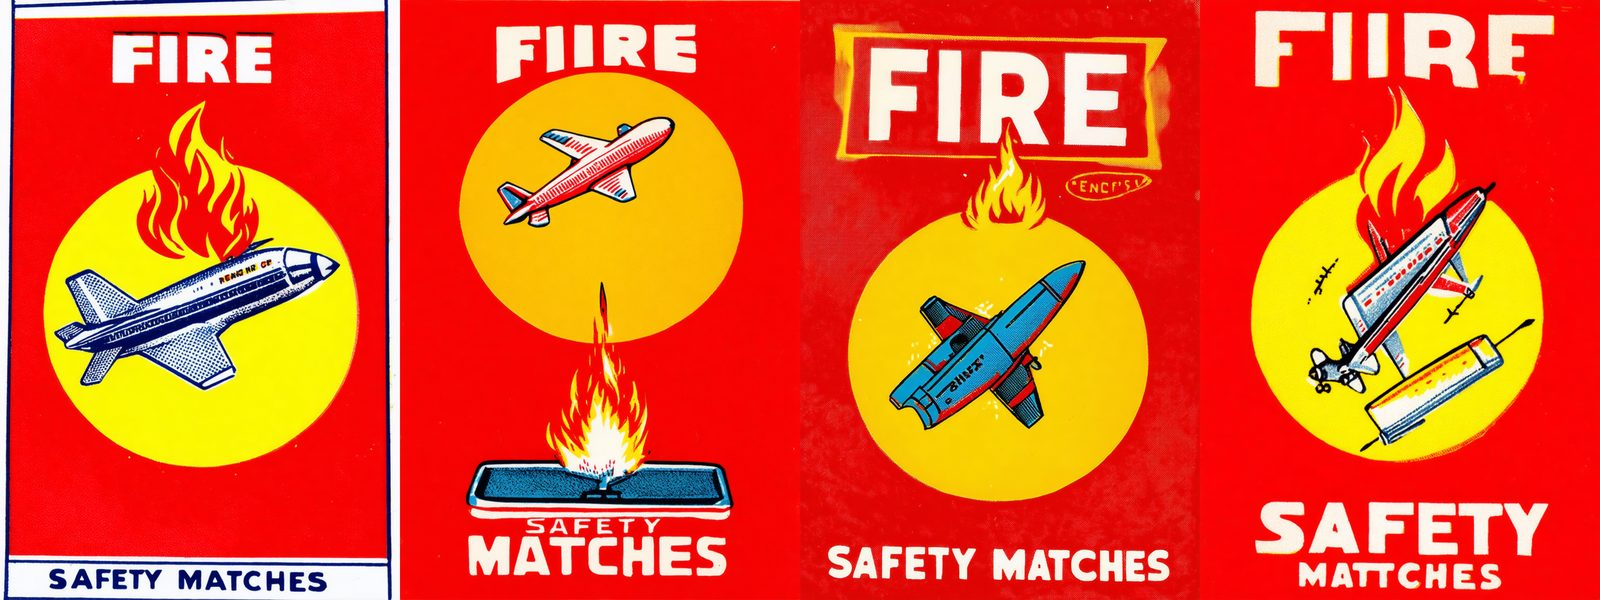

In [16]:
display(gen("phlmx, a matchbox, a burning aeroplane inside an orange circle, red background, headline 'FIRE', text 'Safety Matches'"))


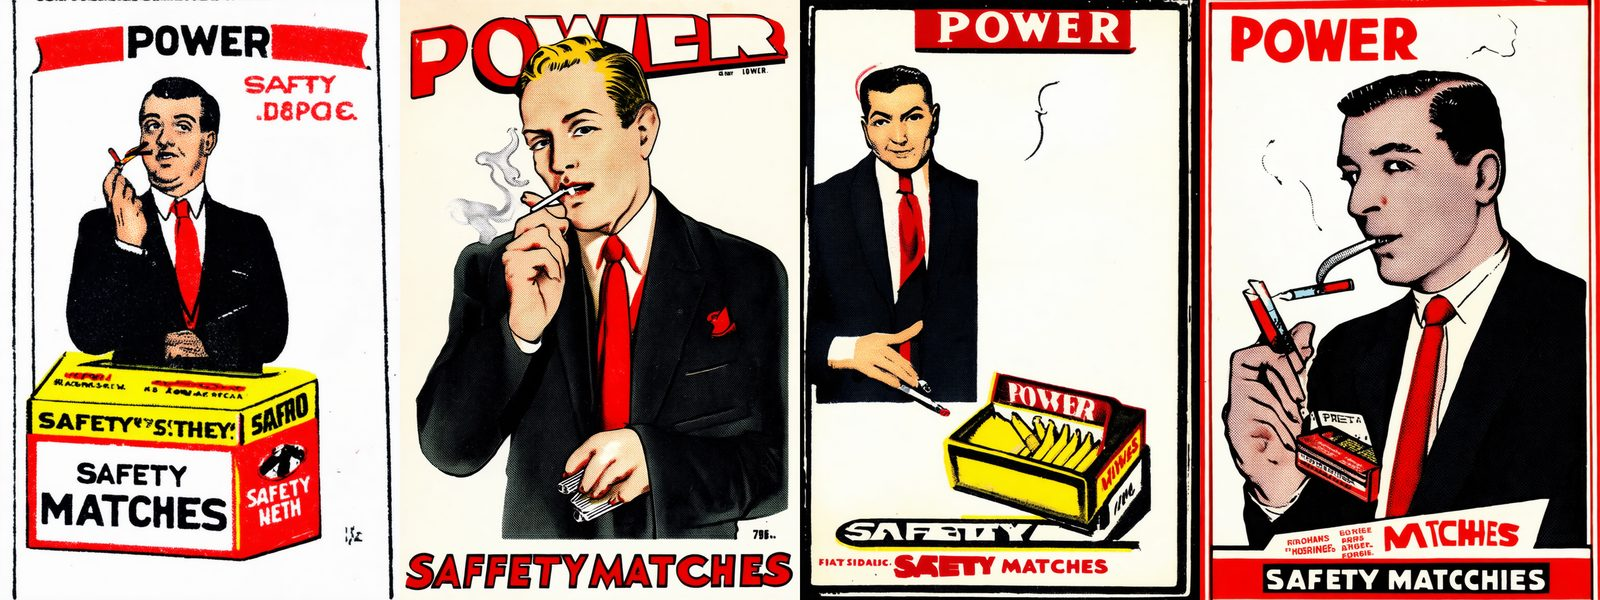

In [17]:
display(gen("phlmx, a matchbox, a man in black suit red tie smoking ciggarette, white background, headline 'POWER', text 'Safety Matches'"))


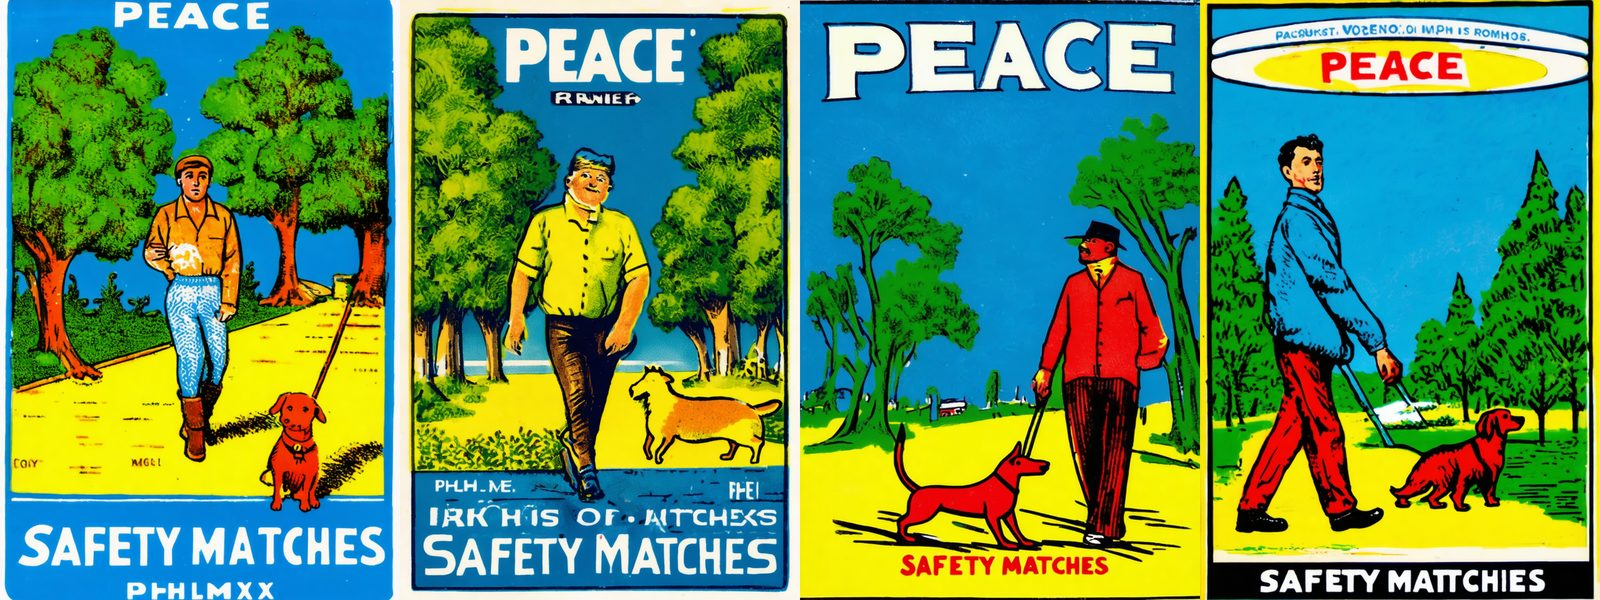

In [18]:
display(gen("phlmx, a matchbox, a man walking his dog in a park with green trees, blue background, headline 'PEACE', text 'Safety Matches'"))


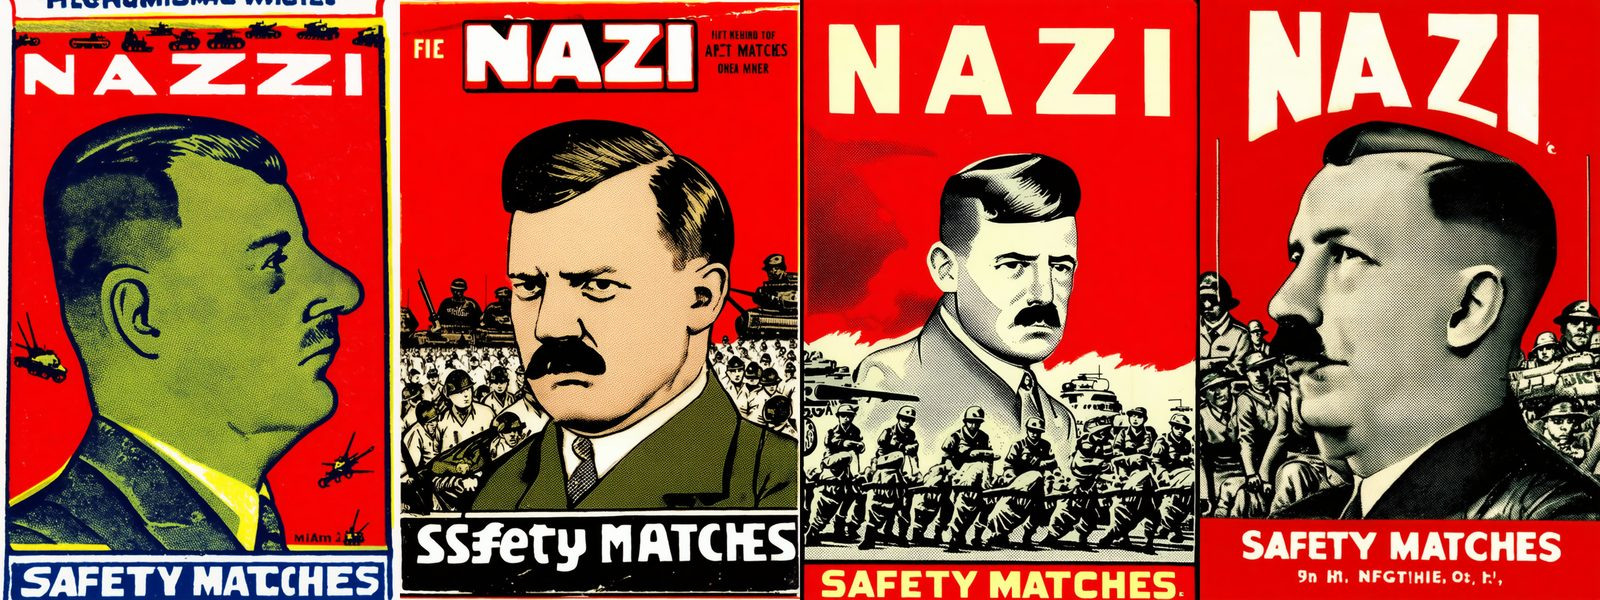

In [19]:
display(gen("phlmx, a matchbox, hitler's face in front sideview in front with his army of nazi soldiers and tanks , red background, headline 'NAZI', text 'Safety Matches'"))


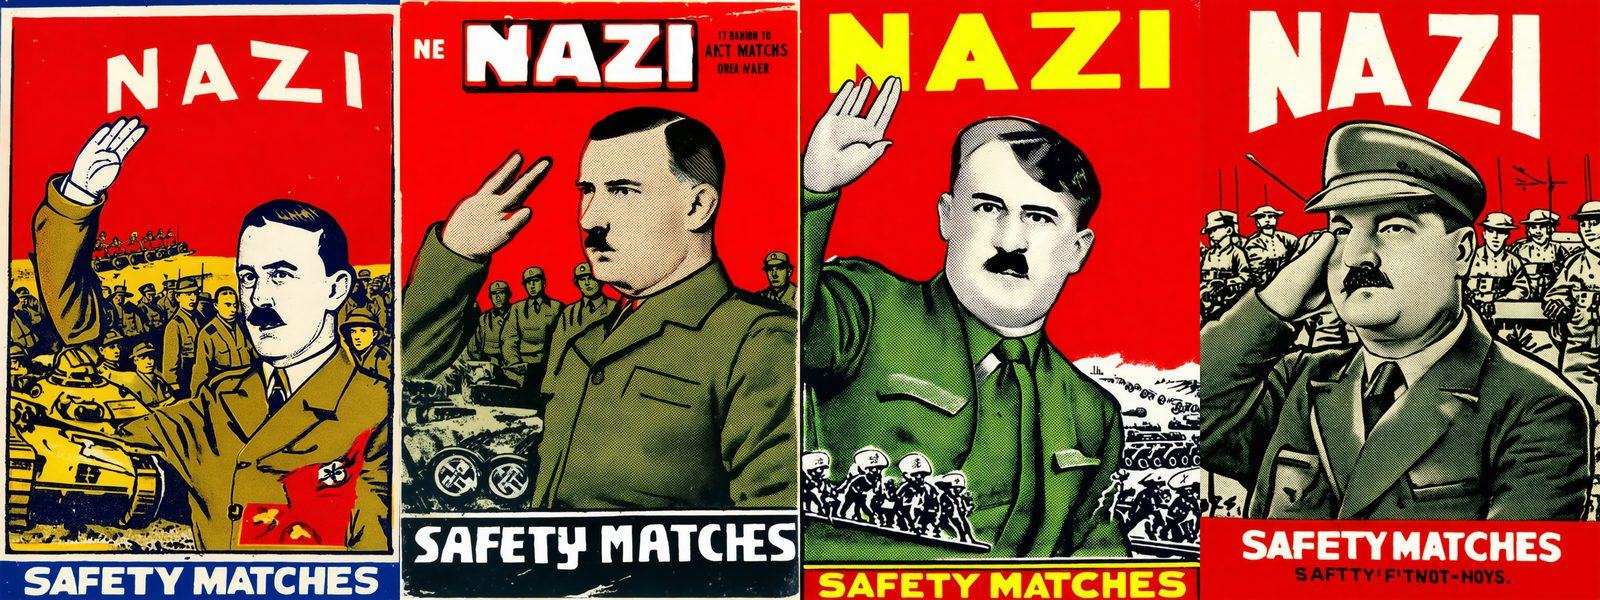

In [20]:
display(gen("phlmx, a matchbox, hitler doing nazi salute in front with his face in sideview in front with his army of nazi soldiers and tanks , red background, headline 'NAZI', text 'Safety Matches'"))


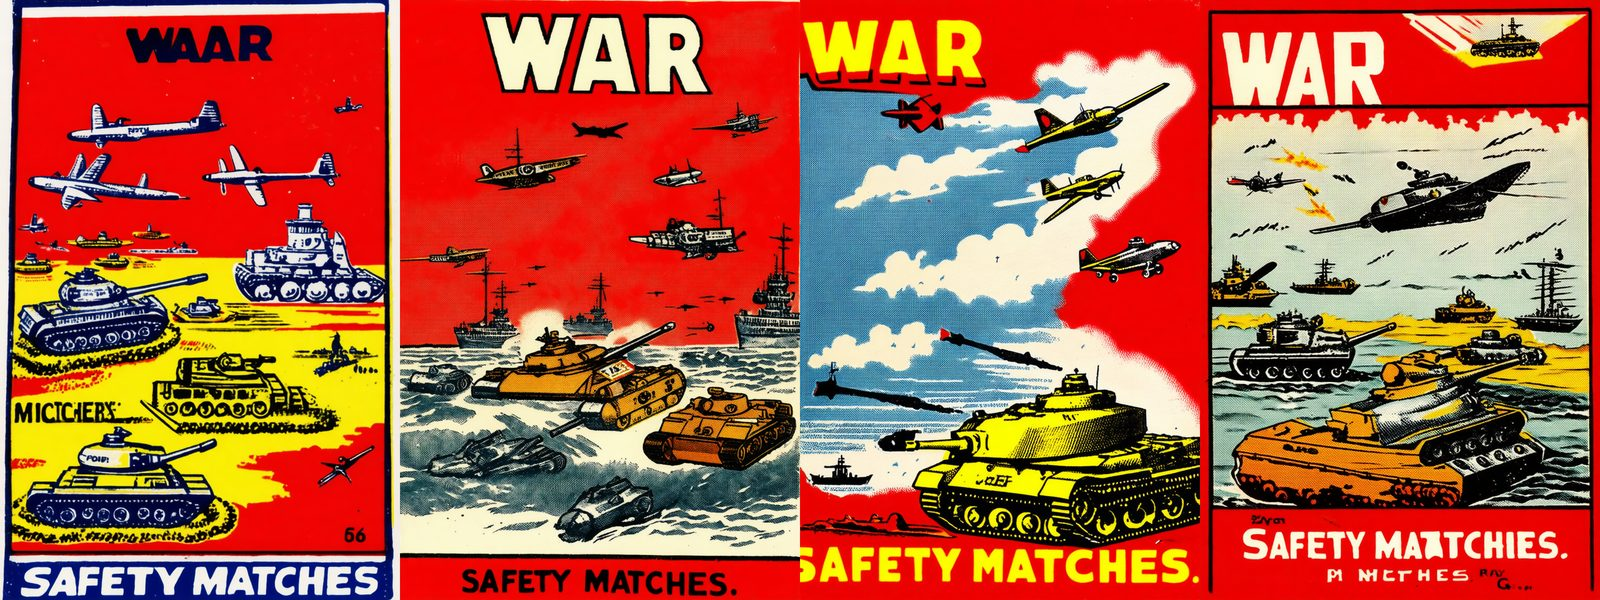

In [21]:
display(gen("phlmx, a matchbox, a world war fight between tanks and planes and ships , red background, headline 'WAR', text 'Safety Matches'"))


---

## Exercises

1. **Flip the convention and watch it fail.** In §3 train the toy flow with target `x0 - eps` but
   keep the diffusers Euler sampler. Then do the same in §12 for one short run and look at the
   grid. The loss still descends: it is the flow version of the prediction-type mismatch in
   ε- and v-prediction models.
2. **Reflow twice.** Apply §4 to `NET_REFLOW` to get a 3-rectified flow. Plot straightness and
   SWD@1 against the reflow round, and against the SWD floor of its own training targets. Where
   does the bias start to cost more than the straightening saves?
3. **Targets beyond attention.** Add the adaLN linears (`norm1.linear`, `norm1_context.linear`)
   and the MLPs (`ff.net.0.proj`, `ff.net.2`) to `LORA_TARGETS`. Compare trainable parameters,
   peak memory, and the held-out velocity curve at equal steps.
4. **Shift at a new resolution.** Train at 256 px and again at 512 px with `train_sched` rebuilt
   with `shift` = 1.0 and 3.0. Evaluate each with the held-out velocity error at fixed σ *and* by
   generating at the matching resolution. Does the lower resolution prefer the lower shift, as
   §5.2's √(m/n) argument predicts?
5. **Uniform vs logit-normal on the real model.** Set `WEIGHTING = "uniform"` (any value the
   helper does not recognise falls back to uniform, per its source) and then try
   `LOSS_WEIGHTING = "sigma_sqrt"`. Compare the per-σ held-out error in §13. Which σ range does
   each one improve?
6. **Sana-600M.** It is the smallest ungated, Apache-2.0 flow-matching DiT in §6's table. Port §8
   to §14 to `SanaPipeline`. Its scheduler config is a `DPMSolverMultistepScheduler` with
   `prediction_type: flow_prediction` and `flow_shift: 3.0`, so check what training sigmas and
   targets that implies before reusing §12.

---

**Next:** compare with notebook 55, which trains the same data on SDXL with the full curation
workflow (caption ablation, checkpoint selection, kohya export). The held-out velocity error from
§11 would be a useful addition to 55 §9's selection rule.
